# CONTEXTO

Você é o primeiro cientista de dados de uma incorporadora imobiliária. A diretoria quer entender melhor a performance de vendas dos empreendimentos e tomar decisões baseadas em dados.

Você recebeu um dataset com o histórico de vendas (`vendas_imoveis.csv`) e precisa gerar insights acionáveis.

## Desafio

### Parte 1 — Análise Exploratória *(25 min)*

Usando Python (pandas), responda:

1. Qual o **ticket médio** por tipologia e por empreendimento?
2. Qual a **taxa de desconto média** (diferença entre valor_tabela e valor_venda) por forma de pagamento?
3. Quais os **top 5 corretores** por VGV (Volume Geral de Vendas)?
4. Qual a **distribuição dos dias para fechar** por origem de lead? Qual canal converte mais rápido?
5. Existe **sazonalidade** nas vendas? (agrupe por mês)

**Entregável:** Notebook (`.ipynb`) ou script (`.py`) com as respostas.

### Parte 2 — Visualização *(15 min)*

Crie **2 visualizações** que você apresentaria para a diretoria:

1. **Evolução mensal do VGV** com breakdown por empreendimento
2. **Uma visualização à sua escolha** que revele um insight relevante para o negócio

**Entregável:** Gráficos (matplotlib, seaborn, plotly — livre escolha). Devem ter título, labels e ser legíveis.

### Parte 3 — SQL + Modelagem *(20 min)*

**3A — SQL:** Escreva uma query que retorne um **ranking de imobiliárias parceiras** com: total de vendas, VGV total, ticket médio, desconto médio concedido e comissão total paga. Ordene por VGV.

**3B — Modelo Preditivo:** Proponha (e se possível implemente) um modelo simples para **prever os dias para fechar uma venda** com base nas features disponíveis. Não precisa ser perfeito — queremos ver seu raciocínio sobre:

- Quais features usaria e por quê
- Qual modelo escolheria e por quê
- Como avaliaria o modelo
- O que faria com mais tempo

**Entregável:** Query SQL + código ou documentação do modelo.

# 0.0. IMPORTS

In [ ]:
import pandas as pd
import numpy as np
import scipy
import sqlite3

import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import RobustScaler, OneHotEncoder, FunctionTransformer, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, KFold, learning_curve, TimeSeriesSplit
from sklearn.linear_model import Ridge, Lasso, ElasticNet, QuantileRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, StackingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.base import clone


import xgboost as xgb
import lightgbm as lgb
import optuna
import time

optuna.logging.set_verbosity(optuna.logging.WARNING)  # silencia log verboso
import warnings; warnings.filterwarnings('ignore')

c:\Users\diabo\Documents\Repositorios\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0.1. Setup

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.family": "DejaVu Sans",
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "axes.labelsize": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

In [ ]:
DATA_PATH       = "vendas_imoveis.csv"
TRAIN_SIZE      = 0.80   
TARGET = 'dias_para_fechar'    
ORDEM_TIPOLOGIA = ["Studio", "1 Quarto", "2 Quartos", "3 Quartos", "Cobertura"]
MES_NOME        = {
    1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr",
    5: "Mai", 6: "Jun", 7: "Jul", 8: "Ago",
    9: "Set", 10: "Out", 11: "Nov", 12: "Dez",
}

## 0.2. Carregamento dos Dados

In [4]:
df = pd.read_csv(DATA_PATH)

## 0.3. Funções auxiliares

In [73]:
def fmt_moeda(valor: float, decimais: int = 1) -> str:
    """Formata valor como 'R$ X.XM' ou 'R$ XXXk'."""
    if valor >= 1e6:
        return f"R$ {valor / 1e6:.{decimais}f}M"
    return f"R$ {valor / 1e3:.0f}k"

In [214]:
def regression_metrics(
    model_name: str,
    y_true: pd.Series,
    y_pred: np.ndarray,
    baseline_mae: float = None,
) -> pd.DataFrame:
    """
    Calcula MAE, RMSE, MSE e R² para um modelo de regressão.

    Parâmetros
    ----------
    model_name   : nome do modelo (exibido na tabela)
    y_true       : valores reais
    y_pred       : predições do modelo
    baseline_mae : MAE do baseline para calcular ganho relativo (opcional)
    """
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)

    result = {
        "Model":     model_name,
        "MAE":       round(mae,  3),
        "RMSE":      round(rmse, 3),
        "MSE":       round(mse,  3),
        "R²":        round(r2,   4),
    }

    if baseline_mae is not None:
        result["vs_Baseline2"] = round(-(mae - baseline_mae), 3)

    return pd.DataFrame([result])


In [231]:
def smoothed_target_encode(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    col: str,
    target: str = TARGET,
    alpha: float = 5.0,
) -> tuple[pd.Series, pd.Series]:
    """
    Smoothed target encoding calculado APENAS no conjunto de treino.
    Novas categorias no teste recebem a global_mean do treino.

    enc(cat) = (n_cat * mean_cat + alpha * global_mean) / (n_cat + alpha)

    Parâmetros
    ----------
    alpha : float
        Força do shrinkage em direção à média global.
        alpha=5 é conservador e funciona bem para grupos com n >= 10.
    """
    stats       = train_df.groupby(col)[target].agg(["mean", "count"])
    global_mean = train_df[target].mean()
    smoothed    = (
        (stats["count"] * stats["mean"] + alpha * global_mean)
        / (stats["count"] + alpha)
    )
    train_enc = train_df[col].map(smoothed).fillna(global_mean)
    test_enc  = test_df[col].map(smoothed).fillna(global_mean)
    return train_enc, test_enc

# 1.0. DESCRIÇÃO DOS DADOS

In [5]:
df1 = df.copy()

In [6]:
df1.head()

,id_venda,data_venda,empreendimento,cidade,tipologia,area_m2,valor_tabela,valor_venda,forma_pagamento,corretor,imobiliaria,origem_lead,dias_para_fechar,comissao_pct
0,1,2023-01-03,Residencial Atlântico,Itapema,Studio,32.7,404294.63,404164.24,Financiamento,Fernanda Alves,Prime Realty,Instagram,58,4.6
1,2,2023-01-03,Mirante Sul,Porto Belo,3 Quartos,114.2,1177359.50,1175313.80,Financiamento,Igor Pereira,Sul Brasil Negócios,Indicação,31,5.1
2,3,2023-01-06,Jardins de Itapema,Itapema,2 Quartos,71.7,619271.07,612267.90,Financiamento,Paula Araújo,Direto com Corretor,Portal,62,3.4
3,4,2023-01-15,Residencial Atlântico,Itapema,2 Quartos,60.2,770728.77,760989.79,Financiamento,Fernanda Alves,Prime Realty,Indicação,21,5.8
4,5,2023-01-15,Grand Maré,Itapema,3 Quartos,124.7,1893644.73,1839491.19,Financiamento,Lucas Ferreira,Sul Brasil Negócios,WhatsApp,35,5.4


## 1.1. Dimensão dos Dados

In [195]:
print( 'Linhas: {}'.format( df1.shape[0] ) )
print( 'Colunas: {}'.format( df1.shape[1] ) )

Linhas: 500
Colunas: 18


## 1.2. Tipo dos Dados

In [8]:
df1.dtypes

id_venda              int64
data_venda           object
empreendimento       object
cidade               object
tipologia            object
area_m2             float64
valor_tabela        float64
valor_venda         float64
forma_pagamento      object
corretor             object
imobiliaria          object
origem_lead          object
dias_para_fechar      int64
comissao_pct        float64
dtype: object

* Data precisa ser do tipo 'datetime'

In [9]:
df1['data_venda'] = pd.to_datetime(df1['data_venda'])
df1 = df1.sort_values("data_venda").reset_index(drop=True)

In [10]:
df1['ano']          = df1['data_venda'].dt.year
df1['mes']          = df1['data_venda'].dt.month
df1['mes_ano']      = df1['data_venda'].dt.to_period('M')   
df1['trimestre']    = df1['data_venda'].dt.quarter

## 1.3. Verificar Dados Nulos

In [11]:
df1.isnull().sum()

id_venda            0
data_venda          0
empreendimento      0
cidade              0
tipologia           0
area_m2             0
valor_tabela        0
valor_venda         0
forma_pagamento     0
corretor            0
imobiliaria         0
origem_lead         0
dias_para_fechar    0
comissao_pct        0
ano                 0
mes                 0
mes_ano             0
trimestre           0
dtype: int64

* Sem dados faltantes

## 1.4. Verificar Dados Duplicados

In [12]:
df1.duplicated().sum()

np.int64(0)

* Sem dados duplicados

## 1.5. Estátistica Descritiva

In [13]:
cat_attributes = df1.select_dtypes(exclude= ['int64', 'float64', 'int32', 'datetime64[ns]'])
num_attributes = df1.select_dtypes(include= ['int64', 'float64', 'int32'])

### 1.5.1. Atributos Numéricos

In [14]:
mean_ = pd.DataFrame(num_attributes.apply(np.mean)).T
median_ = pd.DataFrame(num_attributes.apply(np.median)).T

std_ = pd.DataFrame( num_attributes.apply( np.std ) ).T
min_ = pd.DataFrame( num_attributes.apply( min ) ).T
max_ = pd.DataFrame( num_attributes.apply( max ) ).T
range_ = pd.DataFrame( num_attributes.apply( lambda x: x.max() - x.min() ) ).T
skew_ = pd.DataFrame( num_attributes.apply( lambda x: x.skew() ) ).T
kurtosis_ = pd.DataFrame( num_attributes.apply( lambda x: x.kurtosis() ) ).T

description = pd.concat( [min_, max_, range_, mean_, median_, std_, skew_, kurtosis_] ).T.reset_index()
description.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis']

description.round(2)

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,id_venda,1.00,500.00,499.00,250.50,250.50,144.34,0.00,-1.20
1,area_m2,25.60,199.90,174.30,87.05,76.25,43.02,0.89,0.08
2,valor_tabela,273418.06,7152173.37,6878755.31,1759122.11,1016241.46,1503883.81,1.33,1.05
3,valor_venda,268430.81,7078022.05,6809591.24,1694378.56,966952.23,1450084.13,1.33,1.04
4,dias_para_fechar,1.00,116.00,115.00,33.06,28.00,20.96,1.15,1.33
5,comissao_pct,3.00,6.00,3.00,5.15,5.30,0.62,-1.08,1.40
6,ano,2023.00,2025.00,2.00,2024.01,2024.00,0.82,-0.02,-1.52
7,mes,1.00,12.00,11.00,6.56,7.00,3.87,-0.08,-1.45
8,trimestre,1.00,4.00,3.00,2.54,3.00,1.23,-0.06,-1.59


**Área**
* Amplitude: 25,6 m² a 199,9 m² → portfólio bastante diversificado (studios a apartamentos grandes)
* Média (87 m²) > Mediana (76 m²) → distribuição assimétrica à direita: a maioria dos imóveis é menor, mas alguns grandes puxam a média para cima

**Valor tabela/Valor venda**
* Ambos com skew ≈ 1,33 e kurtosis ≈ 1 → distribuição com cauda direita relevante: poucos imóveis de altíssimo valor
* valor_venda sistematicamente abaixo de valor_tabela → desconto é a norma, não exceção


**Comissão**
* Skew = -1,08 (negativo!) → a maioria recebe comissões altas (próximas de 5-6%), com poucos casos no mínimo de 3%


### 1.5.2. Atributos Categóricos

In [15]:
cat_attributes.describe(include=['object']).T

,count,unique,top,freq
empreendimento,500,7,Villa Portofino,79
cidade,500,3,Itapema,288
tipologia,500,5,2 Quartos,161
forma_pagamento,500,3,Financiamento,283
corretor,500,15,Juliana Souza,44
imobiliaria,500,10,Costa Sul Imobiliária,61
origem_lead,500,5,WhatsApp,152


# 2.0. ANÁLISE EXPLORÁTORIA DE DADOS

In [16]:
df2 = df1.copy()

## 2.1. Análise Univariada

In [ ]:
NUMERICAS = [
    ('area_m2',      'Área (m²)',              '#4C9BE8'),
    ('valor_tabela', 'Valor de Tabela (R$)',    '#5B8DB8'),
    ('valor_venda',  'Valor de Venda (R$)',     '#3A7DC9'),
    ('comissao_pct', 'Comissão (%)',            '#F4A261'),
]

CATEGORICAS = [
    ('cidade',          'Cidade',               '#7B68EE'),
    ('tipologia',       'Tipologia',            '#48CAE4'),
    ('forma_pagamento', 'Forma de Pagamento',   '#F77F00'),
    ('origem_lead',     'Origem do Lead',       '#06D6A0'),
    ('imobiliaria',     'Imobiliária',          '#EF476F'),
    ('empreendimento',  'Empreendimento',       '#118AB2'),
    ('corretor',        'Corretor',             '#9B5DE5'),
]

### 2.1.1. Variavel Resposta

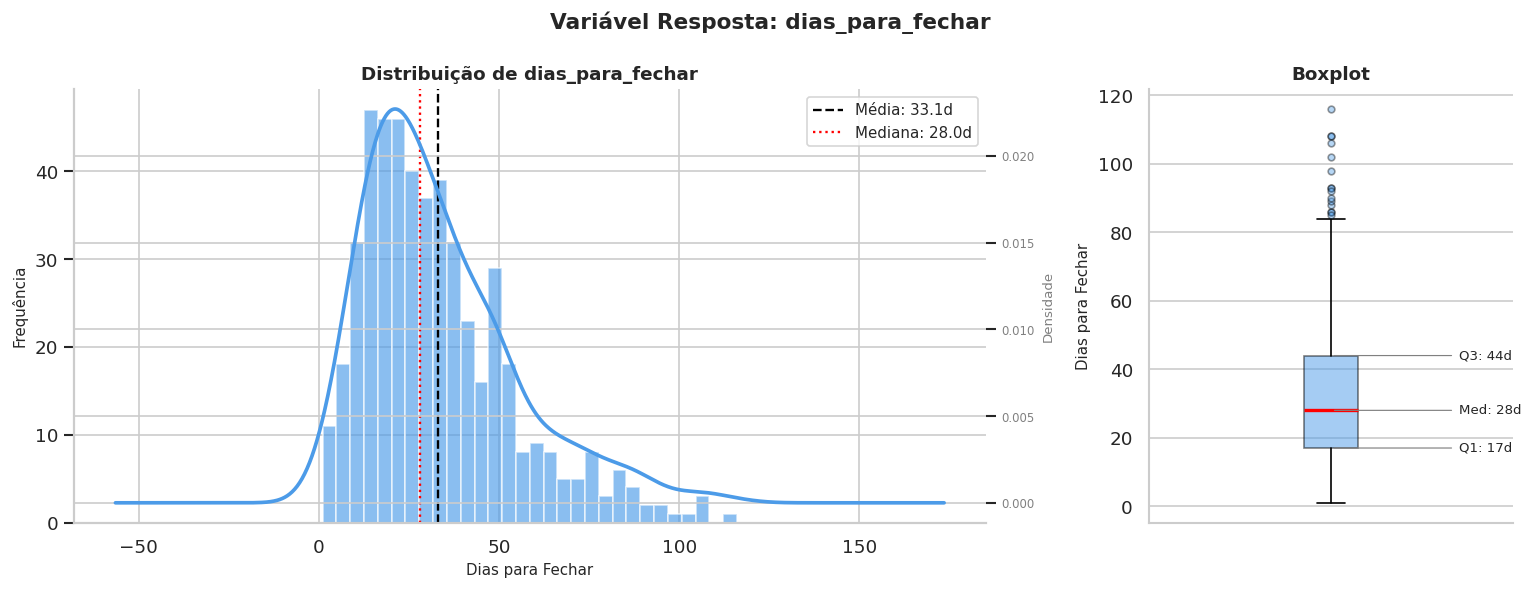

In [18]:
serie = df2[TARGET]

fig = plt.figure(figsize=(13, 5))
gs  = gridspec.GridSpec(1, 2, width_ratios=[2.5, 1], figure=fig)

# Histograma + KDE
ax1     = fig.add_subplot(gs[0])
ax1.hist(serie, bins=30, color="#4C9BE8", alpha=0.65, edgecolor="white", zorder=2)
ax_kde  = ax1.twinx()
serie.plot(kind="kde", ax=ax_kde, color="#4C9BE8", linewidth=2.2)
ax_kde.set_ylabel("Densidade", fontsize=8, color="grey")
ax_kde.tick_params(axis="y", labelcolor="grey", labelsize=7)

ax1.axvline(serie.mean(),   color="black", linestyle="--", linewidth=1.4,
            label=f"Média: {serie.mean():.1f}d")
ax1.axvline(serie.median(), color="red",   linestyle=":",  linewidth=1.4,
            label=f"Mediana: {serie.median():.1f}d")
ax1.set_title("Distribuição de dias_para_fechar")
ax1.set_xlabel("Dias para Fechar")
ax1.set_ylabel("Frequência")
ax1.legend(fontsize=9)

# Boxplot
ax2 = fig.add_subplot(gs[1])
ax2.boxplot(serie, vert=True, patch_artist=True,
            boxprops=dict(facecolor="#4C9BE8", alpha=0.5),
            medianprops=dict(color="red", linewidth=2),
            flierprops=dict(marker="o", markerfacecolor="#4C9BE8",
                            alpha=0.4, markersize=4))

for lbl, val in [("Q1", serie.quantile(.25)), ("Med", serie.median()),
                 ("Q3", serie.quantile(.75))]:
    ax2.annotate(f"{lbl}: {val:.0f}d",
                 xy=(1, val), xytext=(1.35, val),
                 fontsize=8, va="center",
                 arrowprops=dict(arrowstyle="-", color="grey", lw=0.7))
ax2.set_xticks([])
ax2.set_title("Boxplot")
ax2.set_ylabel("Dias para Fechar")

fig.suptitle("Variável Resposta: dias_para_fechar", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

A distribuição de dias para fechar é assimétrica à direita, com maioria das vendas entre 15 e 30 dias e poucos casos que se estendem até cerca de 115 dias. A média maior que a mediana confirma a presença de negociações mais longas. Outliers acima de 80 dias sugerem negociações mais complexas ou de maior valor. **A assimetria favorece o uso de QuantileRegressor e a avaliação por MAE, por serem mais robustos a outliers.**

### 2.1.2. Variáveis Numéricas

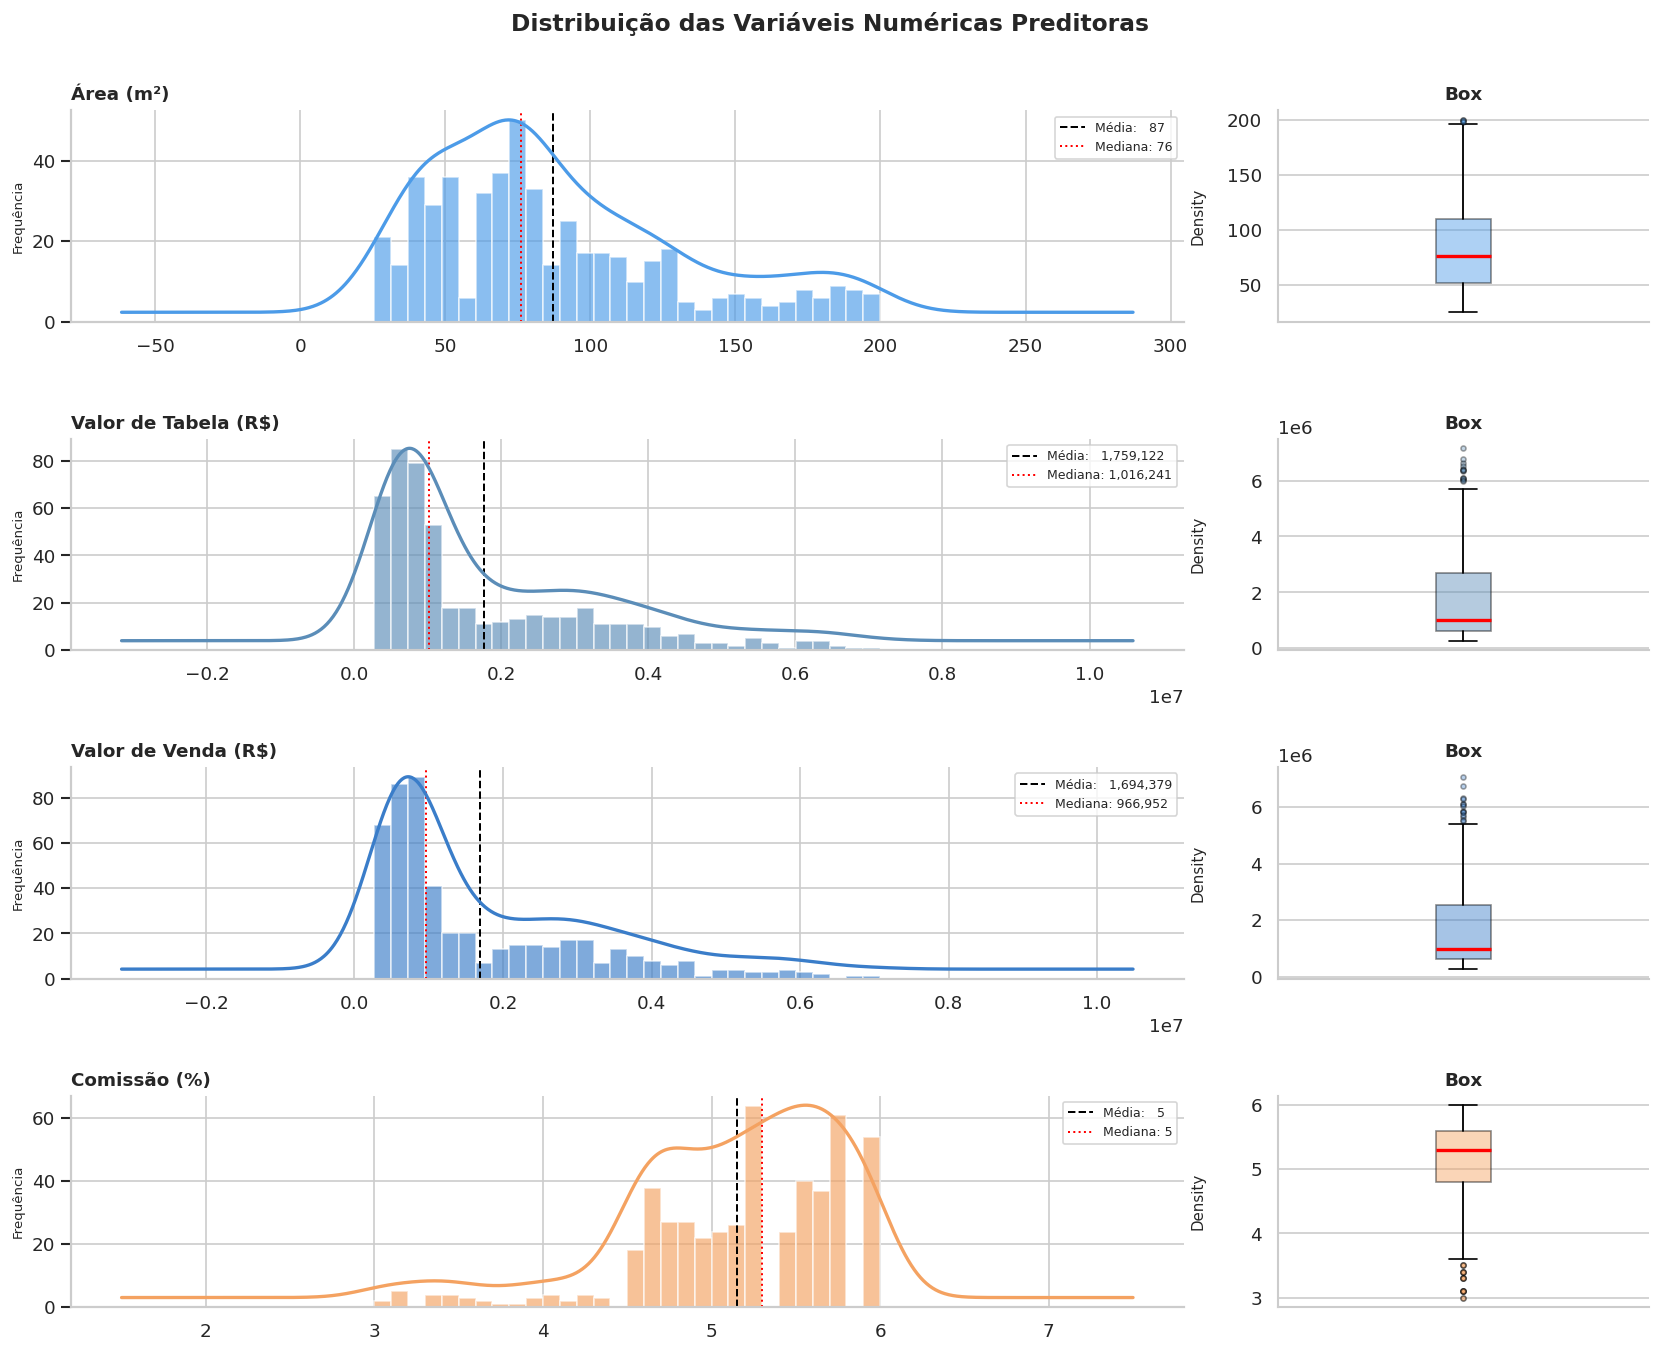

In [196]:
n = len(NUMERICAS)
fig, axes = plt.subplots(n, 2, figsize=(14, n * 2.8),
                         gridspec_kw={'width_ratios': [3, 1]})

for i, (col, label, cor) in enumerate(NUMERICAS):
    serie   = df2[col]
    ax_hist = axes[i, 0]
    ax_box  = axes[i, 1]

    # ── Histograma + KDE ─────────────────────────────────────
    ax_hist.hist(serie, bins=30, color=cor, alpha=0.65,
                 edgecolor='white', zorder=2)

    ax_kde = ax_hist.twinx()
    serie.plot(kind='kde', ax=ax_kde, color=cor, linewidth=2)
    ax_kde.set_yticks([])

    media   = serie.mean()
    mediana = serie.median()
    ax_hist.axvline(media,   color='black', linestyle='--', linewidth=1.2,
                    label=f'Média:   {media:,.0f}')
    ax_hist.axvline(mediana, color='red',   linestyle=':',  linewidth=1.2,
                    label=f'Mediana: {mediana:,.0f}')

    ax_hist.set_title(label, loc='left', pad=6)
    ax_hist.set_ylabel('Frequência', fontsize=8)
    ax_hist.legend(fontsize=7.5, loc='upper right')
    ax_hist.spines[['top', 'right']].set_visible(False)


    # ── Boxplot ──────────────────────────────────────────────
    ax_box.boxplot(serie.dropna(), vert=True, patch_artist=True,
                   boxprops=dict(facecolor=cor, alpha=0.45),
                   medianprops=dict(color='red', linewidth=2),
                   whiskerprops=dict(linewidth=1.1),
                   flierprops=dict(marker='o', markerfacecolor=cor,
                                   alpha=0.35, markersize=3))
    ax_box.set_xticks([])
    ax_box.set_title('Box', pad=6)
    ax_box.spines[['top', 'right']].set_visible(False)

fig.suptitle('Distribuição das Variáveis Numéricas Preditoras',
             fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout(h_pad=1.8)
plt.show()

* Área apresenta assimetria à direita e distribuição bimodal (~70m² e ~100m²), refletindo unidades compactas e maiores no portfólio, com alguns outliers de grande metragem.

* Valor de tabela e valor de venda também são fortemente assimétricos à direita, com poucos imóveis de alto valor puxando a média e outliers acima de R$5M.

* A proximidade entre valor de tabela e valor de venda indica descontos relativamente pequenos no fechamento das negociações.

### 2.1.3. Variáveis Categóricas

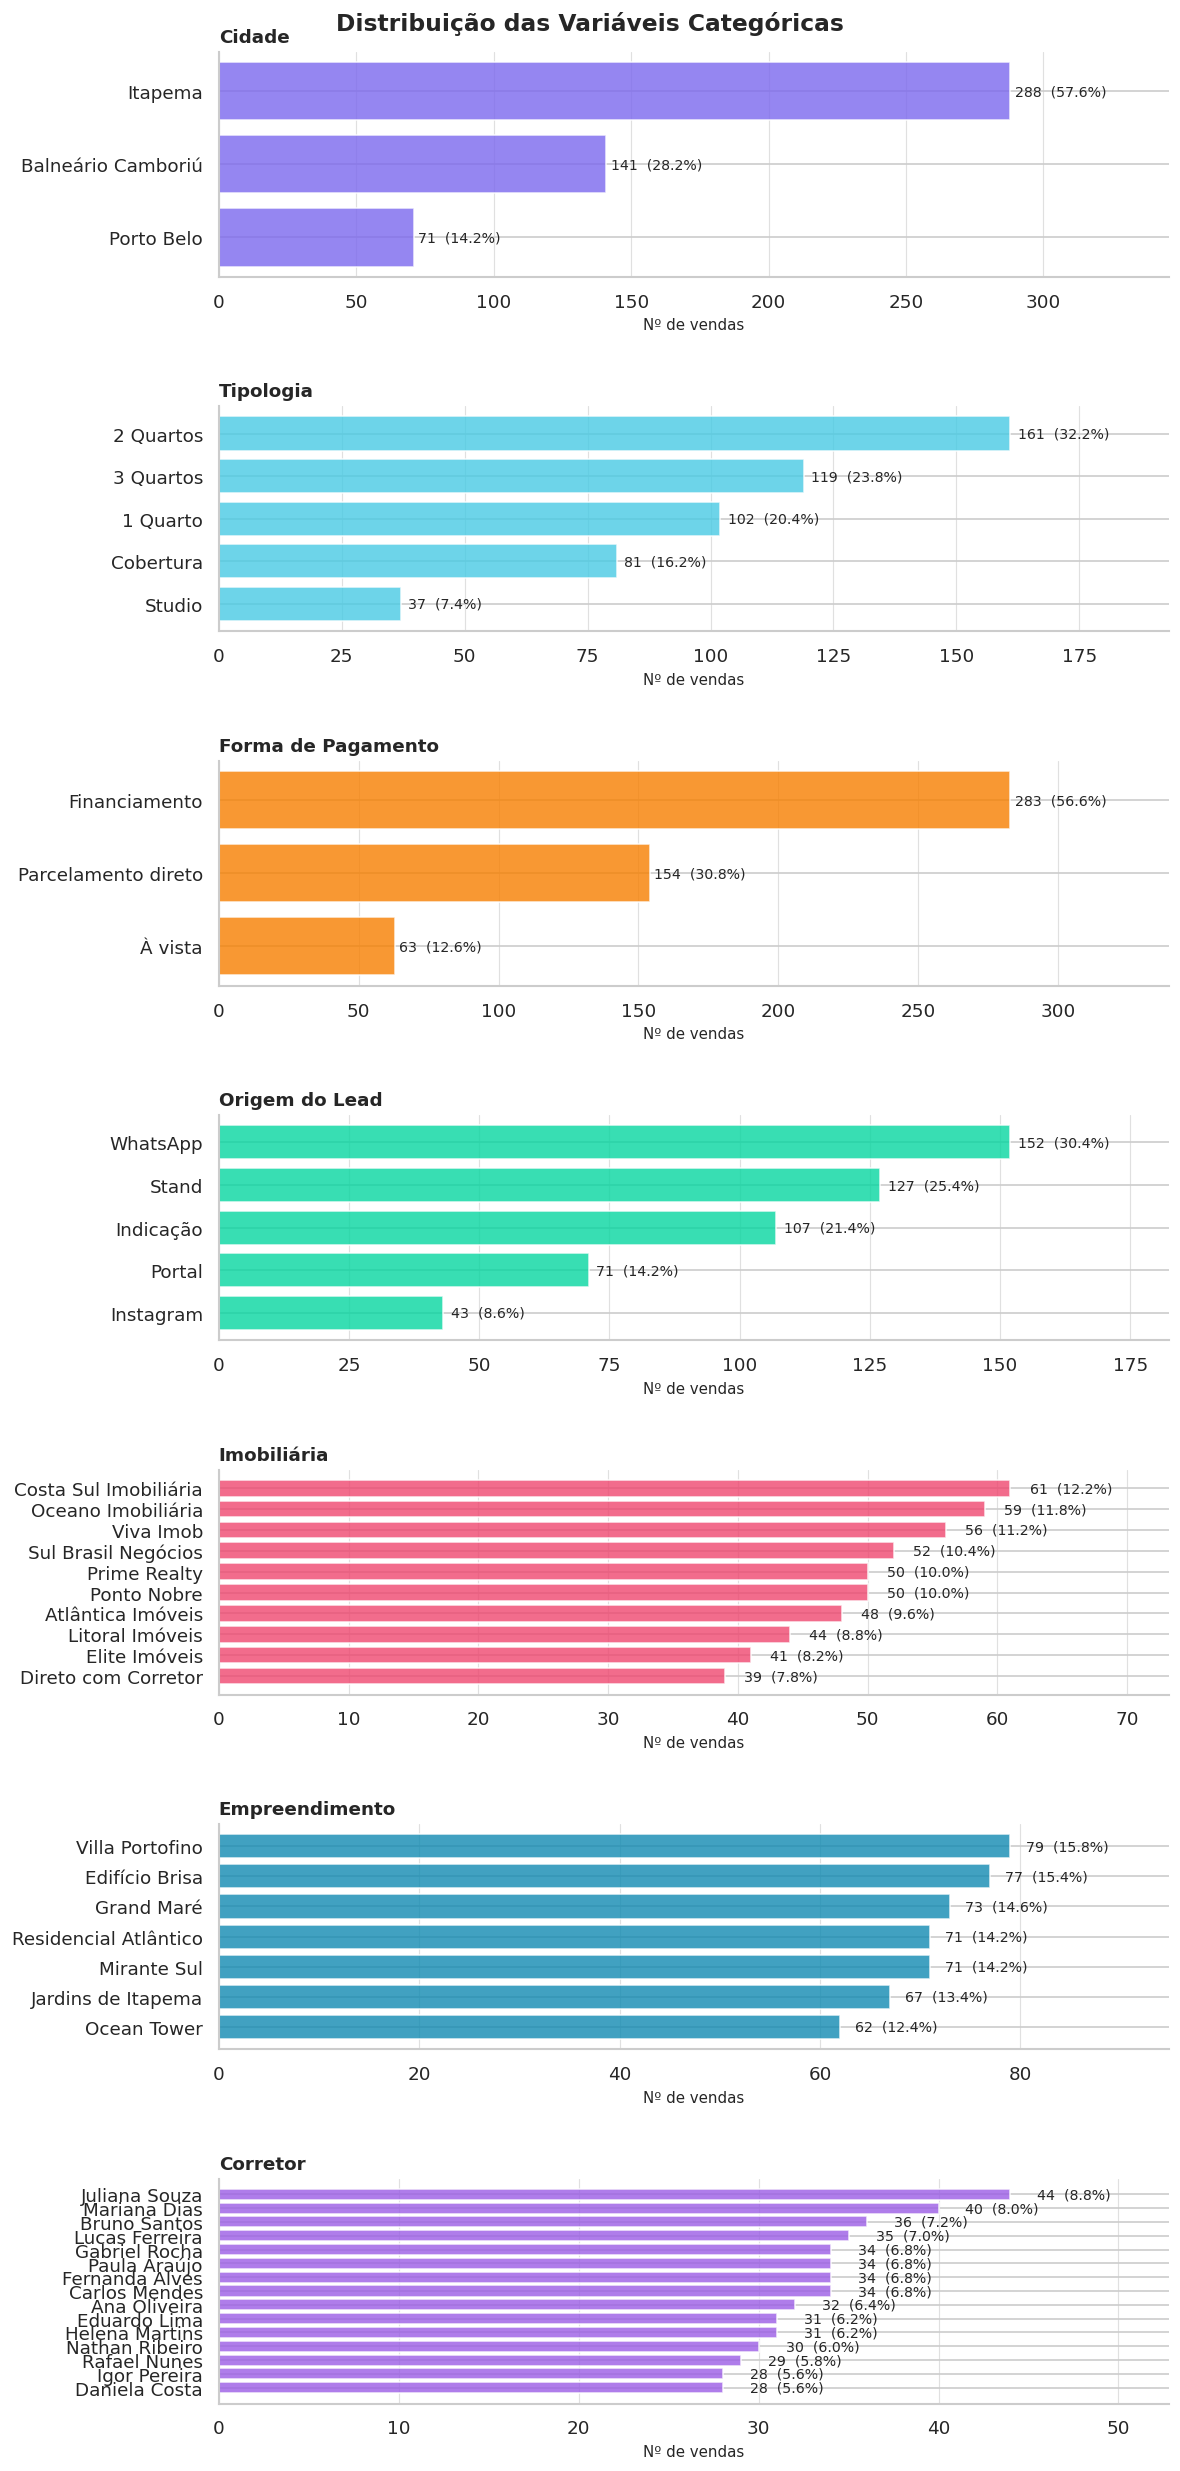

In [ ]:
n = len(CATEGORICAS)
fig, axes = plt.subplots(n, 1, figsize=(10, n * 3.0))

# Garante que axes seja sempre iterável (caso n=1)
if n == 1:
    axes = [axes]

for ax, (col, label, cor) in zip(axes, CATEGORICAS):

    ordem   = df2[col].value_counts().head(15).index
    contagem = df2[col].value_counts().loc[ordem]
    total   = len(df2)

    ax.barh(ordem[::-1], contagem[::-1],
            color=cor, alpha=0.80, edgecolor="white")

    for j, (cat, v) in enumerate(zip(ordem[::-1], contagem[::-1])):
        ax.text(v + total * 0.003, j,
                f"{v}  ({v/total*100:.1f}%)",
                va="center", fontsize=8.5)

    ax.set_title(f"{label}", loc="left", fontweight="bold", pad=6)
    ax.set_xlabel("Nº de vendas")
    ax.set_xlim(0, contagem.max() * 1.20)   # espaço para os rótulos
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", color="#E0E0E0", linewidth=0.7)

fig.suptitle("Distribuição das Variáveis Categóricas",
             fontsize=14, fontweight="bold")
plt.tight_layout(h_pad=2.5)
plt.show()

* Cidade é dominada por Itapema, seguida por Balneário Camboriú e Porto Belo; como **cada empreendimento pertence a uma única cidade, a variável é redundante e pode ser removida.**

* Financiamento é a forma de pagamento mais comum e pode aumentar o tempo médio de fechamento devido a etapas bancárias.

* Corretores têm distribuição relativamente homogênea -> o uso de target encoding suavizado para evitar overfitting.

### 2.1.4. Temporal

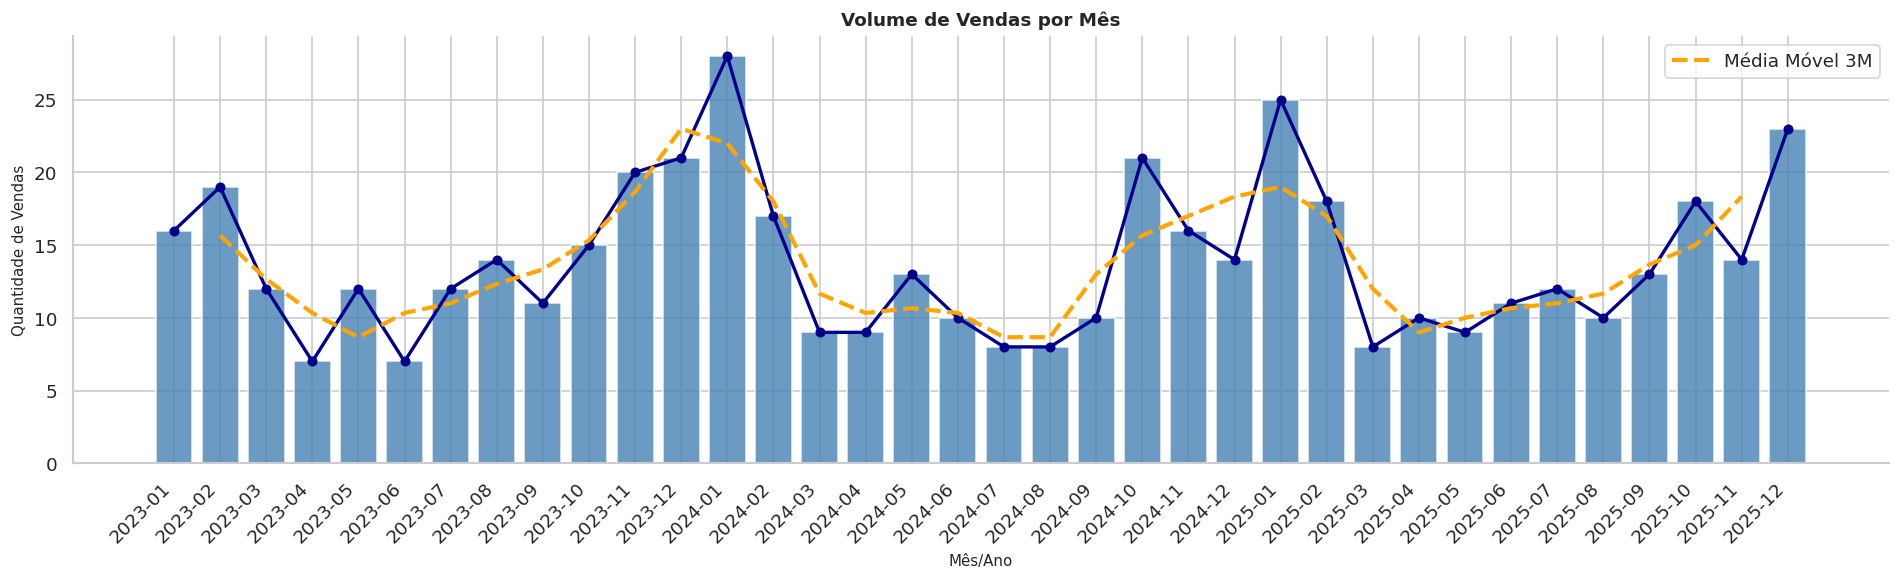

In [200]:
# ============================================================
# DISTRIBUIÇÃO DE VENDAS AO LONGO DO TEMPO
# ============================================================

vendas_mes = df2.groupby('mes_ano').size().reset_index(name='qtd_vendas')
vendas_mes['mes_ano_str'] = vendas_mes['mes_ano'].astype(str)

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(vendas_mes['mes_ano_str'], vendas_mes['qtd_vendas'],
       color='steelblue', alpha=0.8, edgecolor='white')
ax.plot(vendas_mes['mes_ano_str'], vendas_mes['qtd_vendas'],
        color='darkblue', marker='o', linewidth=2, markersize=5)

# Média móvel de 3 meses
vendas_mes['mm3'] = vendas_mes['qtd_vendas'].rolling(3, center=True).mean()
ax.plot(vendas_mes['mes_ano_str'], vendas_mes['mm3'],
        color='orange', linewidth=2.5, linestyle='--', label='Média Móvel 3M')

ax.set_title('Volume de Vendas por Mês', fontweight='bold')
ax.set_xlabel('Mês/Ano')
ax.set_ylabel('Quantidade de Vendas')
plt.xticks(rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

* O volume de vendas apresenta sazonalidade, com picos no início do ano e queda no segundo trimestre.

* Não há tendência clara de crescimento ou queda ao longo dos 36 meses, indicando mercado relativamente estável.

## 2.2. Análise Bivariada

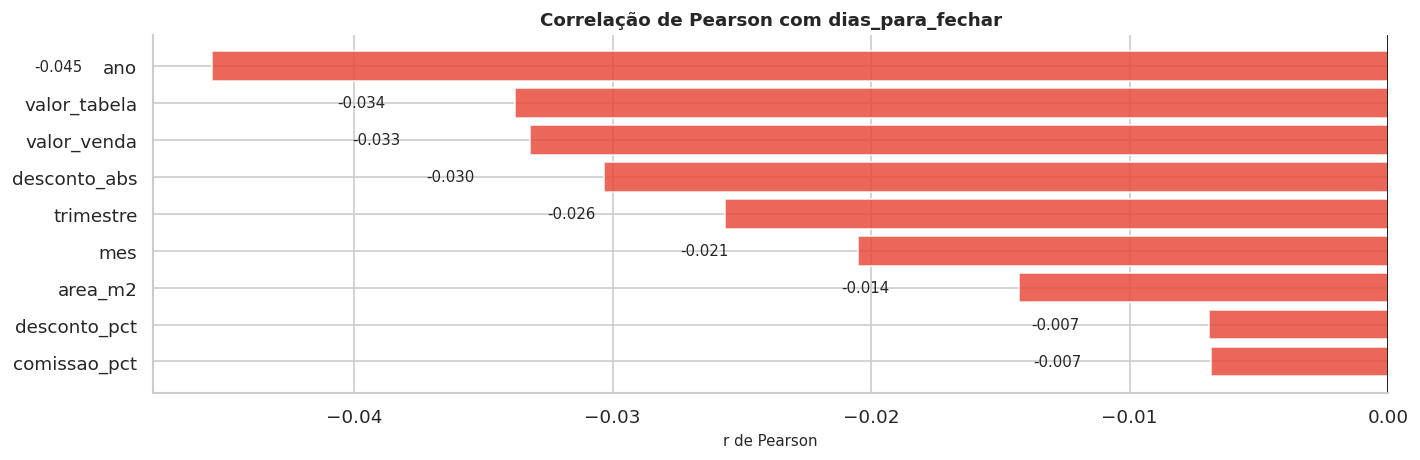

In [ ]:
# CORRELAÇÃO COM A VARIAVEL RESPOSTA

corr_alvo = (
    df2.select_dtypes(include="number")
    .drop(columns=["id_venda"])
    .corr()["dias_para_fechar"]
    .drop("dias_para_fechar")
    .sort_values(key=abs)
)

fig, ax = plt.subplots(figsize=(12, 4))
cores = ["#E74C3C" if v < 0 else "#2E86C1" for v in corr_alvo.values]
ax.barh(corr_alvo.index, corr_alvo.values, color=cores, alpha=0.85, edgecolor="white")
ax.axvline(0, color="black", linewidth=1)
for i, (col, val) in enumerate(corr_alvo.items()):
    ax.text(val + (0.005 if val >= 0 else -0.005), i,
            f"{val:.3f}", va="center",
            ha="left" if val >= 0 else "right", fontsize=9)
ax.set_title("Correlação de Pearson com dias_para_fechar", fontweight="bold")
ax.set_xlabel("r de Pearson")
plt.tight_layout()
plt.show()

* As variáveis numéricas apresentam **correlação praticamente nula com dias_para_fechar** (|r| < 0.05), indicando ausência de relação linear relevante.

* Isso sugere que nenhuma feature numérica explica isoladamente o tempo de fechamento.

* Modelos baseados apenas nas numéricas tendem a performar próximo do baseline.

## 2.3. Perguntas

### Q1 — Ticket médio por tipologia e por empreendimento

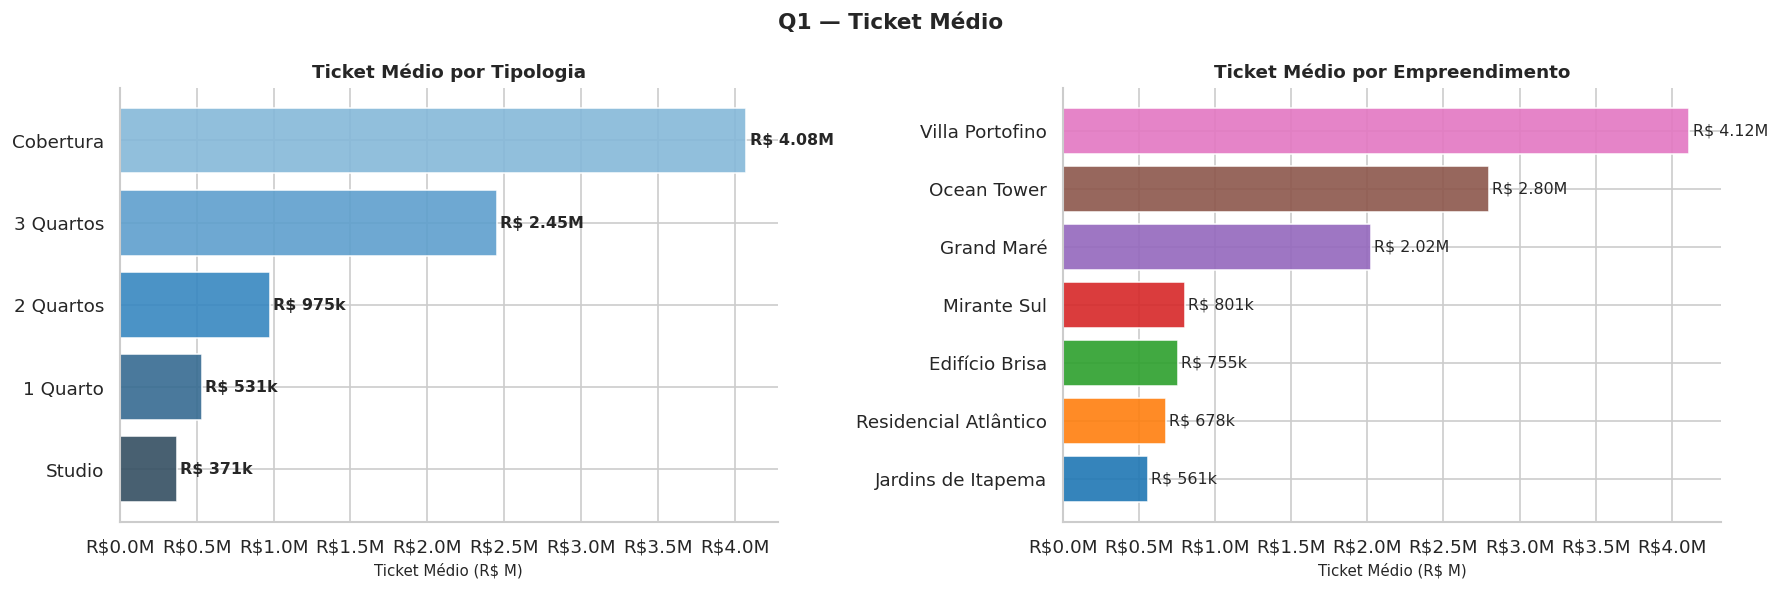

=== Ticket por Tipologia ===
           Vendas Ticket Médio        VGV
tipologia                                
Cobertura      81      R$ 4.1M  R$ 330.3M
3 Quartos     119      R$ 2.5M  R$ 292.0M
2 Quartos     161      R$ 975k  R$ 157.0M
1 Quarto      102      R$ 531k   R$ 54.2M
Studio         37      R$ 371k   R$ 13.7M

=== Ticket por Empreendimento ===
                       Vendas Ticket Médio        VGV
empreendimento                                       
Villa Portofino            79      R$ 4.1M  R$ 325.2M
Ocean Tower                62      R$ 2.8M  R$ 173.7M
Grand Maré                 73      R$ 2.0M  R$ 147.6M
Mirante Sul                71      R$ 801k   R$ 56.9M
Edifício Brisa             77      R$ 755k   R$ 58.1M
Residencial Atlântico      71      R$ 678k   R$ 48.1M
Jardins de Itapema         67      R$ 561k   R$ 37.6M


In [217]:
ticket_tip = (
    df2.groupby("tipologia")["valor_venda"]
    .agg(qtd="count", ticket_medio="mean", vgv_total="sum")
    .reindex(ORDEM_TIPOLOGIA)
)

ticket_emp = (
    df2.groupby("empreendimento")["valor_venda"]
    .agg(qtd="count", ticket_medio="mean", vgv_total="sum")
    .sort_values("ticket_medio", ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Tipologia — horizontal
ax = axes[0]
cores_tip = sns.color_palette("Blues_d", len(ORDEM_TIPOLOGIA))
bars = ax.barh(ticket_tip.index, ticket_tip["ticket_medio"] / 1e6,
               color=cores_tip[::-1], edgecolor="white", alpha=0.9)
for bar, val in zip(bars, ticket_tip["ticket_medio"]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
            fmt_moeda(val, 2), va="center", fontsize=9.5, fontweight="bold")
ax.set_title("Ticket Médio por Tipologia")
ax.set_xlabel("Ticket Médio (R$ M)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R${v:.1f}M"))

# Empreendimento
ax2 = axes[1]
cores_emp = sns.color_palette("tab10", len(ticket_emp))
bars2 = ax2.barh(ticket_emp.index, ticket_emp["ticket_medio"] / 1e6,
                 color=cores_emp, edgecolor="white", alpha=0.9)
for bar, val in zip(bars2, ticket_emp["ticket_medio"]):
    ax2.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
             fmt_moeda(val, 2), va="center", fontsize=9.5)
ax2.set_title("Ticket Médio por Empreendimento")
ax2.set_xlabel("Ticket Médio (R$ M)")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R${v:.1f}M"))

fig.suptitle("Q1 — Ticket Médio", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Tabelas numéricas
print("=== Ticket por Tipologia ===")
print(ticket_tip.sort_values("ticket_medio", ascending=False).assign(
    ticket_fmt=ticket_tip["ticket_medio"].apply(fmt_moeda),
    vgv_fmt=ticket_tip["vgv_total"].apply(fmt_moeda),
)[["qtd", "ticket_fmt", "vgv_fmt"]].rename(
    columns={"qtd": "Vendas", "ticket_fmt": "Ticket Médio", "vgv_fmt": "VGV"}
).to_string())

print("\n=== Ticket por Empreendimento ===")
print(ticket_emp.sort_values("ticket_medio", ascending=False).assign(
    ticket_fmt=ticket_emp["ticket_medio"].apply(fmt_moeda),
    vgv_fmt=ticket_emp["vgv_total"].apply(fmt_moeda),
)[["qtd", "ticket_fmt", "vgv_fmt"]].rename(
    columns={"qtd": "Vendas", "ticket_fmt": "Ticket Médio", "vgv_fmt": "VGV"}
).to_string())

* O ticket médio aumenta consistentemente com o tamanho da unidade, de studios até coberturas.

* Coberturas e unidades de 3 quartos concentram os maiores valores de venda.

* Entre os empreendimentos, Villa Portofino, Ocean Tower e Grand Maré apresentam os maiores tickets médios.

* O portfólio se divide entre empreendimentos de alto padrão (tickets acima de ~R$2M) e médio padrão (abaixo de ~R$1M).

* **Empreendimento e tipologia capturam dimensões diferentes do valor do imóvel e devem ser mantidos como features separadas.**

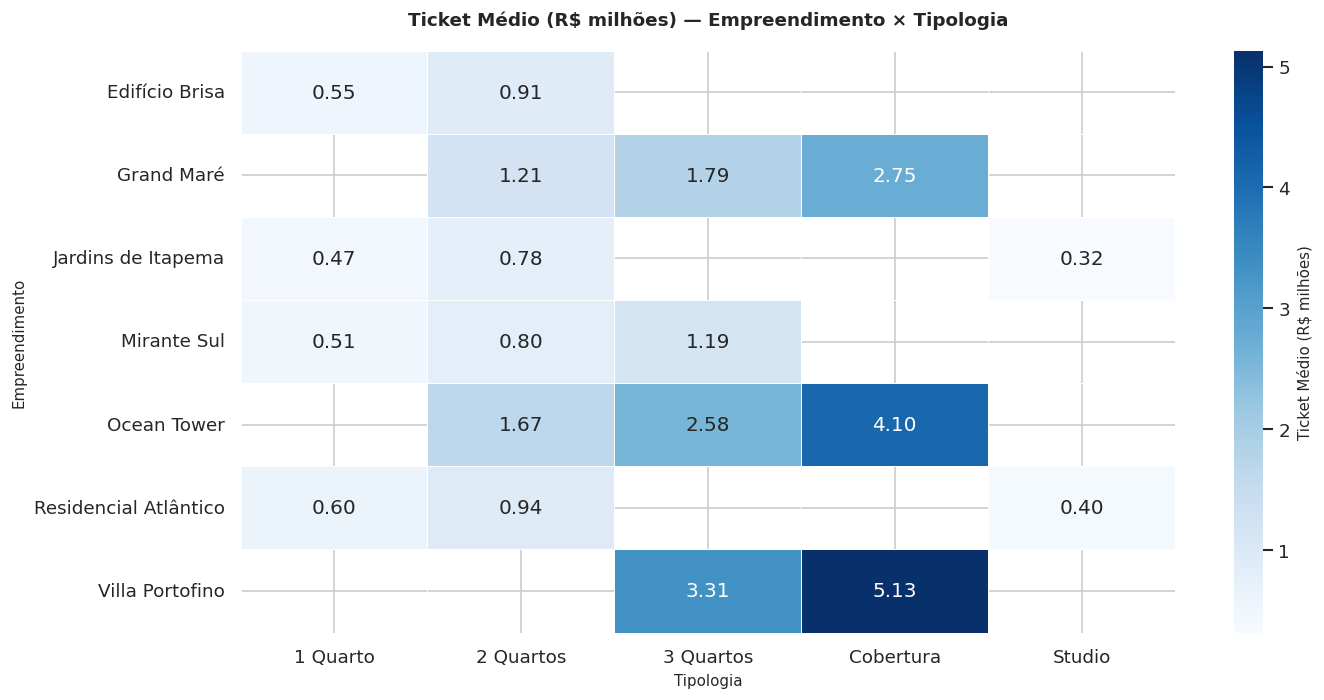

In [218]:
# ============================================================
# ANÁLISE MULTIVARIADA: Ticket Médio por Empreendimento × Tipologia
# ============================================================
ticket_pivot = (
    df2.groupby(['empreendimento', 'tipologia'])['valor_venda']
    .mean()
    .unstack(fill_value=np.nan)
    / 1e6
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    ticket_pivot, annot=True, fmt='.2f', cmap='Blues',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Ticket Médio (R$ milhões)'}
)
ax.set_title('Ticket Médio (R$ milhões) — Empreendimento × Tipologia', fontweight='bold', pad=15)
ax.set_xlabel('Tipologia')
ax.set_ylabel('Empreendimento')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


* Villa Portofino opera apenas em unidades de alto padrão (3Q e cobertura), com os maiores tickets do portfólio.

* Ocean Tower e Grand Maré ocupam o segmento de alto padrão sem presença em studios.

* Os demais empreendimentos concentram unidades menores e tickets abaixo de R$1M.

### Q2 — Taxa de desconto média por forma de pagamento

=== Desconto por Forma de Pagamento ===
                     Vendas Desconto % Médio Desconto Abs. Médio Desconto Total
forma_pagamento                                                                
À vista                  63            8.99%             R$ 176k       R$ 11.1M
Parcelamento direto     154            4.33%              R$ 72k       R$ 11.1M
Financiamento           283            2.08%              R$ 36k       R$ 10.2M


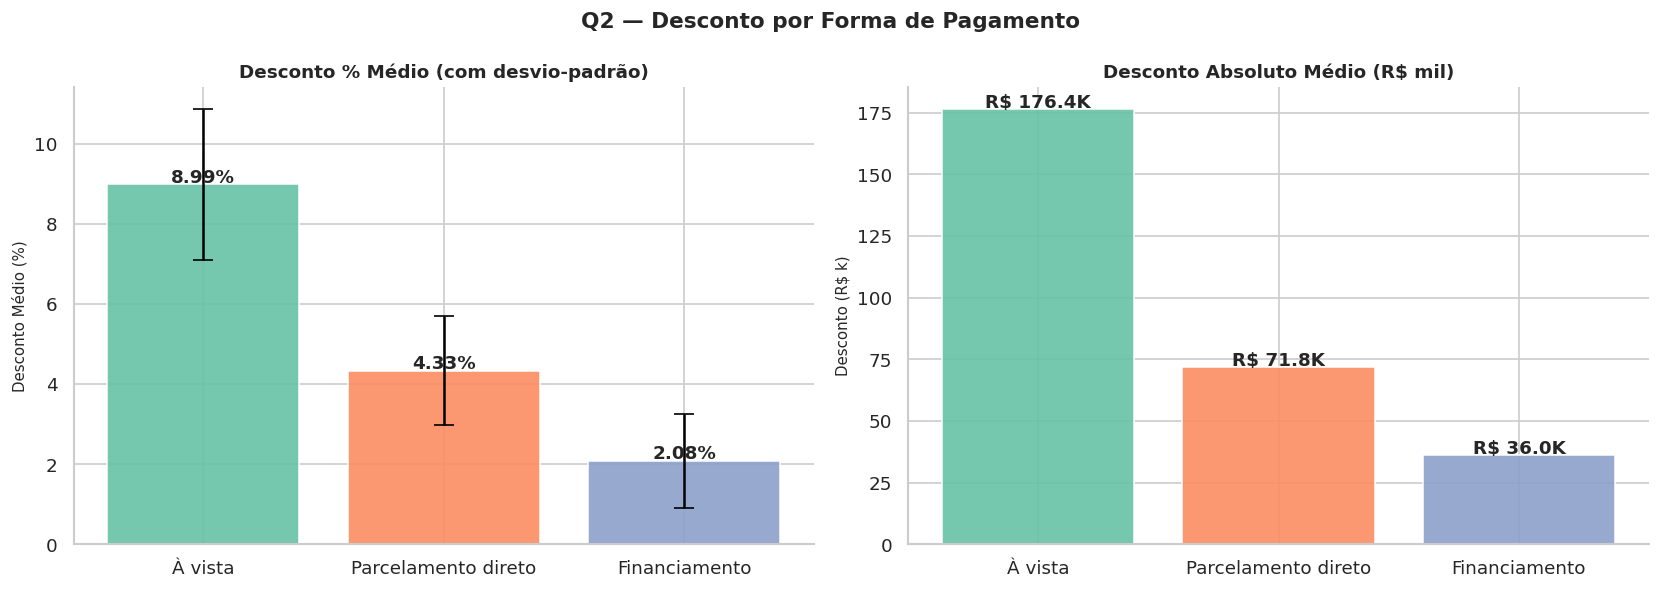

In [29]:
df2["desconto_pct"] = (
    (df2["valor_tabela"] - df2["valor_venda"]) / df2["valor_tabela"] * 100
)
df2["desconto_abs"] = df2["valor_tabela"] - df2["valor_venda"]

desc_pgto = (
    df2.groupby("forma_pagamento")
    .agg(
        qtd=("valor_venda", "count"),
        desc_pct_medio=("desconto_pct", "mean"),
        desc_pct_dp=("desconto_pct", "std"),
        desc_abs_medio=("desconto_abs", "mean"),
        desc_total=("desconto_abs", "sum"),
    )
    .sort_values("desc_pct_medio", ascending=False)
)

print("=== Desconto por Forma de Pagamento ===")
print(
    desc_pgto.assign(
        desc_pct=desc_pgto["desc_pct_medio"].apply(lambda v: f"{v:.2f}%"),
        desc_abs=desc_pgto["desc_abs_medio"].apply(fmt_moeda),
        desc_tot=desc_pgto["desc_total"].apply(fmt_moeda),
    )[["qtd", "desc_pct", "desc_abs", "desc_tot"]].rename(
        columns={
            "qtd": "Vendas", "desc_pct": "Desconto % Médio",
            "desc_abs": "Desconto Abs. Médio", "desc_tot": "Desconto Total",
        }
    ).to_string()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
formas = desc_pgto.index.tolist()
cores_fp = sns.color_palette("Set2", len(formas))

# Desconto %
ax = axes[0]
bars = ax.bar(formas, desc_pgto["desc_pct_medio"],
              color=cores_fp, edgecolor="white", alpha=0.9)
ax.errorbar(formas, desc_pgto["desc_pct_medio"],
            yerr=desc_pgto["desc_pct_dp"],
            fmt="none", color="black", capsize=6, linewidth=1.5)
for bar, val in zip(bars, desc_pgto["desc_pct_medio"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05, f"{val:.2f}%",
            ha="center", fontsize=11, fontweight="bold")
ax.set_title("Desconto % Médio (com desvio-padrão)")
ax.set_ylabel("Desconto Médio (%)")

# Desconto absoluto
ax2 = axes[1]
bars2 = ax2.bar(formas, desc_pgto["desc_abs_medio"] / 1e3,
                color=cores_fp, edgecolor="white", alpha=0.9)
for bar, val in zip(bars2, desc_pgto["desc_abs_medio"]):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5, f"R$ {val/1e3:.1f}K",
             ha="center", fontsize=11, fontweight="bold")
ax2.set_title("Desconto Absoluto Médio (R$ mil)")
ax2.set_ylabel("Desconto (R$ k)")

fig.suptitle("Q2 — Desconto por Forma de Pagamento", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### Q3 — Top 5 corretores por VGV

=== Top 5 Corretores por VGV ===
 ranking       corretor  Vendas VGV Total Ticket Médio  Dias Mediano Desconto Médio
       1  Juliana Souza      44  R$ 71.4M      R$ 1.6M          25.0           4.2%
       2   Bruno Santos      36  R$ 69.3M      R$ 1.9M          29.5           3.5%
       3   Mariana Dias      40  R$ 65.8M      R$ 1.6M          32.0           3.2%
       4 Nathan Ribeiro      30  R$ 61.0M      R$ 2.0M          30.5           3.6%
       5   Rafael Nunes      29  R$ 59.0M      R$ 2.0M          29.0           3.8%


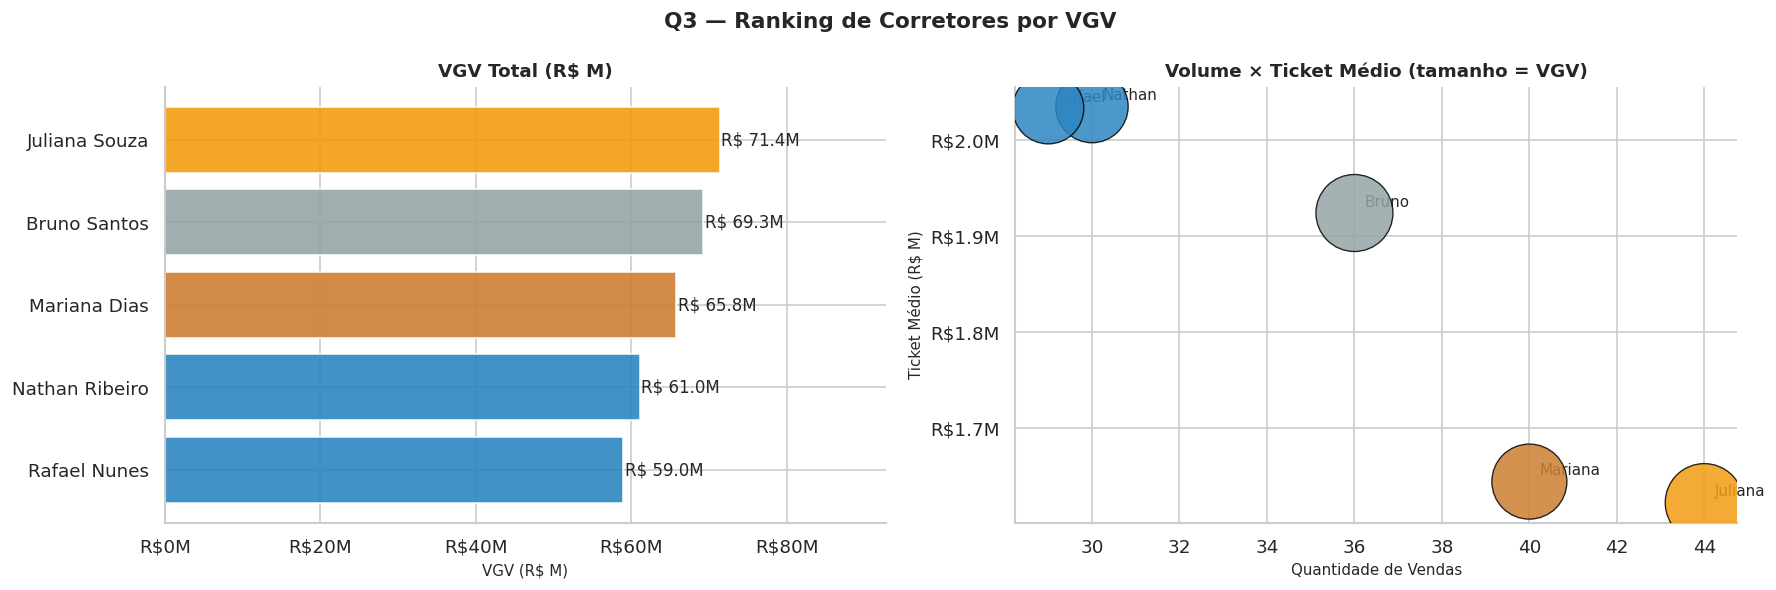

In [31]:
ranking_corretores = (
    df2.groupby("corretor")
    .agg(
        qtd_vendas=("valor_venda", "count"),
        vgv_total=("valor_venda", "sum"),
        ticket_medio=("valor_venda", "mean"),
        dias_mediano=("dias_para_fechar", "median"),
        desconto_medio=("desconto_pct", "mean"),
    )
    .sort_values("vgv_total", ascending=False)
    .reset_index()
)
ranking_corretores.insert(0, "ranking", range(1, len(ranking_corretores) + 1))
top5 = ranking_corretores.head(5)

print("=== Top 5 Corretores por VGV ===")
print(
    top5.assign(
        vgv=top5["vgv_total"].apply(fmt_moeda),
        ticket=top5["ticket_medio"].apply(fmt_moeda),
        desc=top5["desconto_medio"].apply(lambda v: f"{v:.1f}%"),
    )[["ranking", "corretor", "qtd_vendas", "vgv", "ticket", "dias_mediano", "desc"]]
    .rename(
        columns={
            "qtd_vendas": "Vendas", "vgv": "VGV Total",
            "ticket": "Ticket Médio", "dias_mediano": "Dias Mediano",
            "desc": "Desconto Médio",
        }
    )
    .to_string(index=False)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
MEDALHAS = ["#F39C12", "#95A5A6", "#CD7F32", "#2E86C1", "#2E86C1"]

# VGV total (horizontal)
ax = axes[0]
bars = ax.barh(top5["corretor"][::-1], top5["vgv_total"][::-1] / 1e6,
               color=MEDALHAS[::-1], edgecolor="white", alpha=0.9)
for bar, val in zip(bars, top5["vgv_total"][::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            fmt_moeda(val), va="center", fontsize=10)
ax.set_title("VGV Total (R$ M)")
ax.set_xlabel("VGV (R$ M)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R${v:.0f}M"))
ax.set_xlim(0, top5["vgv_total"].max() / 1e6 * 1.3)

# Scatter: qtd vendas vs ticket médio
ax2 = axes[1]
ax2.scatter(
    top5["qtd_vendas"], top5["ticket_medio"] / 1e6,
    s=top5["vgv_total"] / top5["vgv_total"].max() * 2200,
    c=MEDALHAS, alpha=0.85, edgecolors="black", linewidth=0.8, zorder=5,
)
for _, row in top5.iterrows():
    ax2.annotate(
        row["corretor"].split()[0],
        (row["qtd_vendas"], row["ticket_medio"] / 1e6),
        xytext=(6, 4), textcoords="offset points", fontsize=9,
    )
ax2.set_title("Volume × Ticket Médio (tamanho = VGV)")
ax2.set_xlabel("Quantidade de Vendas")
ax2.set_ylabel("Ticket Médio (R$ M)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R${v:.1f}M"))

fig.suptitle("Q3 — Ranking de Corretores por VGV", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


* Os cinco principais corretores concentram cerca de metade do VGV total.

* Há dois perfis de alta performance: corretores de alto volume com tickets menores e corretores de menor volume com tickets mais altos. Ambos os perfis contribuem de forma complementar para o resultado comercial.

### Q4 — Distribuição de dias para fechar por canal de origem

=== Velocidade de Conversão por Canal ===
origem_lead  qtd  mediana  media  desvio  p25  p75
      Stand  127     15.0   15.5     6.8 11.0 21.0
  Indicação  107     23.0   23.7     8.8 17.0 31.0
   WhatsApp  152     36.0   34.9    12.4 26.0 44.0
     Portal   71     53.0   53.4    19.5 40.0 65.0
  Instagram   43     69.0   68.2    23.9 50.5 84.5

Canal mais rápido: Stand (15 dias mediana)


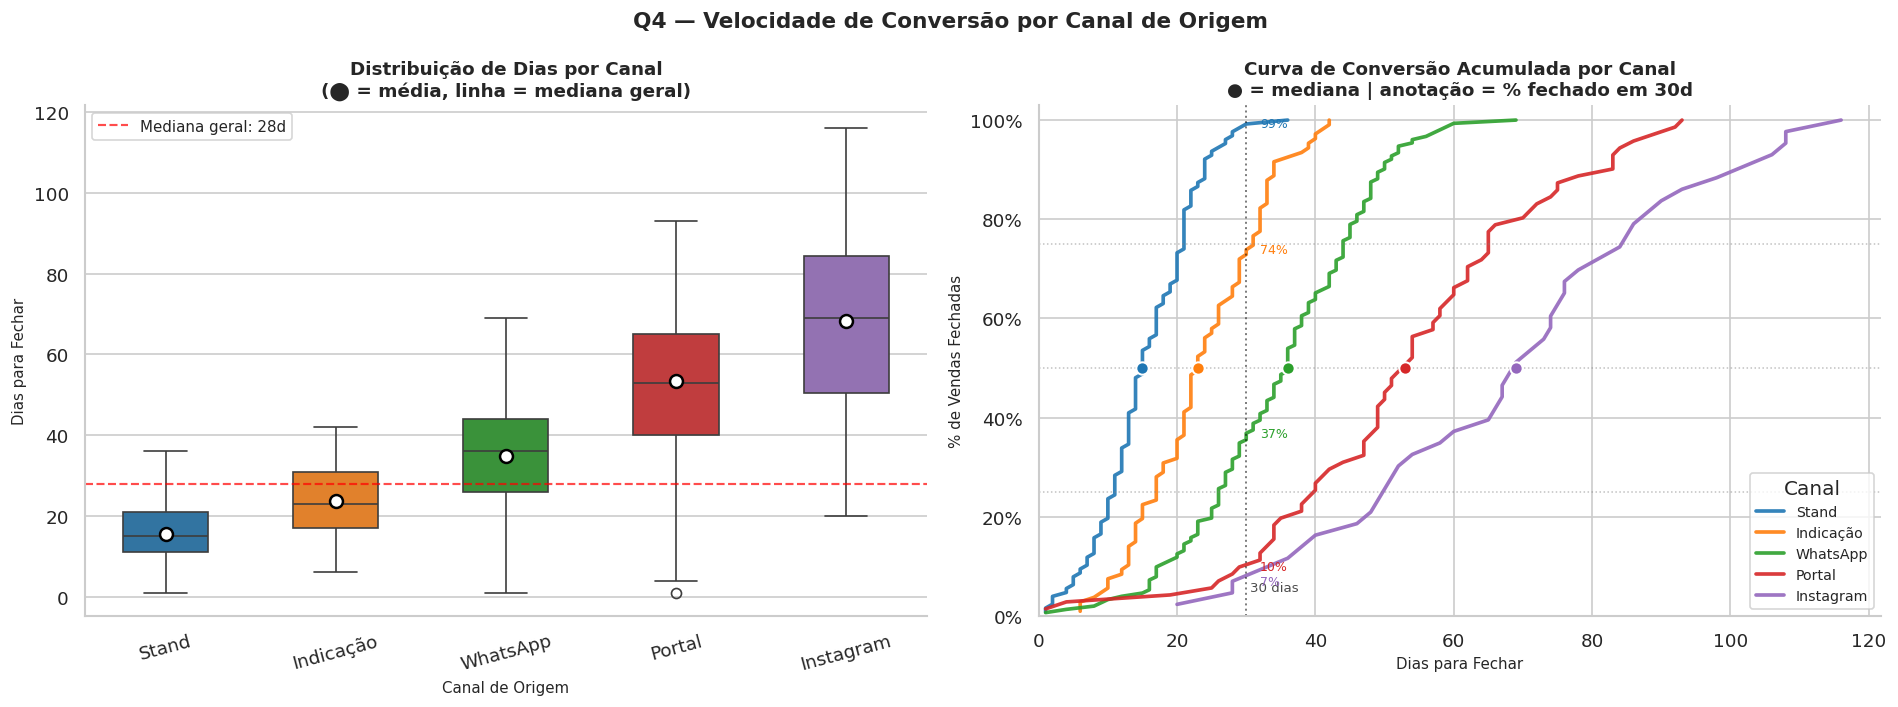


  % de vendas fechadas por canal em cada prazo:
  ───────────────────────────────────────────────────────
  Canal              ≤15d    ≤30d    ≤45d   Mediana
  ───────────────────────────────────────────────────────
  Stand             53.5%   99.2%  100.0%      15d
  Indicação         22.4%   73.8%  100.0%      23d
  WhatsApp           4.6%   36.8%   78.9%      36d
  Portal             2.8%    9.9%   31.0%      53d
  Instagram          0.0%    7.0%   16.3%      69d


In [33]:
dias_lead = (
    df2.groupby("origem_lead")["dias_para_fechar"]
    .agg(
        qtd="count",
        mediana="median",
        media="mean",
        desvio="std",
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75),
    )
    .sort_values("mediana")
    .reset_index()
)

print("=== Velocidade de Conversão por Canal ===")
print(dias_lead.round(1).to_string(index=False))
canal_rapido = dias_lead.iloc[0]["origem_lead"]
med_rapido   = dias_lead.iloc[0]["mediana"]
print(f"\nCanal mais rápido: {canal_rapido} ({med_rapido:.0f} dias mediana)")

# ── Gráfico 1: Boxplot + média ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
order_r = dias_lead["origem_lead"].tolist()
palette = dict(zip(order_r, sns.color_palette("tab10", len(order_r))))

ax = axes[0]
sns.boxplot(data=df2, x="origem_lead", y="dias_para_fechar",
            order=order_r, palette=palette, ax=ax, width=0.5)
medias = dias_lead.set_index("origem_lead")["media"]
for i, canal in enumerate(order_r):
    ax.scatter(i, medias[canal], color="white", s=60, zorder=5,
               edgecolors="black", linewidth=1.5)
ax.axhline(df2["dias_para_fechar"].median(),
           color="red", linestyle="--", linewidth=1.3, alpha=0.7,
           label=f"Mediana geral: {df2['dias_para_fechar'].median():.0f}d")
ax.set_title("Distribuição de Dias por Canal\n(⬤ = média, linha = mediana geral)")
ax.set_xlabel("Canal de Origem")
ax.set_ylabel("Dias para Fechar")
ax.tick_params(axis="x", rotation=15)
ax.legend(fontsize=9)

# ── Gráfico 2: ECDF por canal ──────────────────────────────────────────────
ax2 = axes[1]
for canal in order_r:
    dados  = df2[df2["origem_lead"] == canal]["dias_para_fechar"].sort_values()
    ecdf_y = np.arange(1, len(dados) + 1) / len(dados) * 100
    ax2.plot(dados, ecdf_y, label=canal, color=palette[canal],
             linewidth=2.2, alpha=0.9)
    idx_50 = np.searchsorted(ecdf_y, 50)
    if idx_50 < len(dados):
        ax2.scatter(dados.iloc[idx_50], 50, color=palette[canal],
                    s=55, zorder=5, edgecolors="white", linewidth=1.2)

for pct in [25, 50, 75]:
    ax2.axhline(pct, color="grey", linestyle=":", linewidth=0.9, alpha=0.5)

ax2.axvline(30, color="black", linestyle=":", linewidth=1.2, alpha=0.5)
ax2.text(30.5, 5, "30 dias", fontsize=8, color="black", alpha=0.7)

# Anotação: % convertida em 30 dias
for canal in order_r:
    dados  = df2[df2["origem_lead"] == canal]["dias_para_fechar"]
    pct_30 = (dados <= 30).mean() * 100
    ax2.annotate(f"{pct_30:.0f}%",
                 xy=(30, pct_30), xytext=(32, pct_30),
                 fontsize=7.5, color=palette[canal], va="center")

ax2.set_title("Curva de Conversão Acumulada por Canal\n● = mediana | anotação = % fechado em 30d")
ax2.set_xlabel("Dias para Fechar")
ax2.set_ylabel("% de Vendas Fechadas")
ax2.set_xlim(0)
ax2.set_ylim(0, 103)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax2.legend(title="Canal", fontsize=8.5, loc="lower right")

fig.suptitle("Q4 — Velocidade de Conversão por Canal de Origem",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Tabela: % fechado por prazo
print("\n  % de vendas fechadas por canal em cada prazo:")
print("  " + "─" * 55)
print(f"  {'Canal':<15} {'≤15d':>7} {'≤30d':>7} {'≤45d':>7}  {'Mediana':>8}")
print("  " + "─" * 55)
for _, row in dias_lead.iterrows():
    dados = df2[df2["origem_lead"] == row["origem_lead"]]["dias_para_fechar"]
    print(f"  {row['origem_lead']:<15}"
          f" {(dados<=15).mean()*100:>6.1f}%"
          f" {(dados<=30).mean()*100:>6.1f}%"
          f" {(dados<=45).mean()*100:>6.1f}%"
          f"  {row['mediana']:>6.0f}d")

* **A origem do lead é o principal fator que influencia o tempo de fechamento.**

* Stand é o canal mais rápido, seguido por indicação e WhatsApp.

* Portal e Instagram apresentam ciclos de venda mais longos, com Instagram sendo o mais lento.

* Leads presenciais ou por indicação tendem a chegar mais qualificados e com maior intenção de compra.

### Q5 — Sazonalidade nas vendas

=== Sazonalidade (consolidado por mês) ===
Mês  Vendas         VGV  Dias Mediano
Jan      69 93630102.94          28.0
Fev      54 88374220.62          33.5
Mar      29 64425807.59          26.0
Abr      26 34573883.22          29.0
Mai      34 54306136.98          28.5
Jun      28 44840076.67          30.5
Jul      32 64817029.30          27.0
Ago      32 58439948.92          28.5
Set      34 62109307.76          25.5
Out      54 99920666.39          27.5
Nov      50 82588254.87          32.5
Dez      58 99163842.91          26.0

=== Índice de Sazonalidade (>1 = acima da média) ===
Mês  Vendas  Índice
Jan      69    1.66
Dez      58    1.39
Out      54    1.30
Fev      54    1.30
Nov      50    1.20
Mai      34    0.82
Set      34    0.82
Jul      32    0.77
Ago      32    0.77
Mar      29    0.70
Jun      28    0.67
Abr      26    0.62


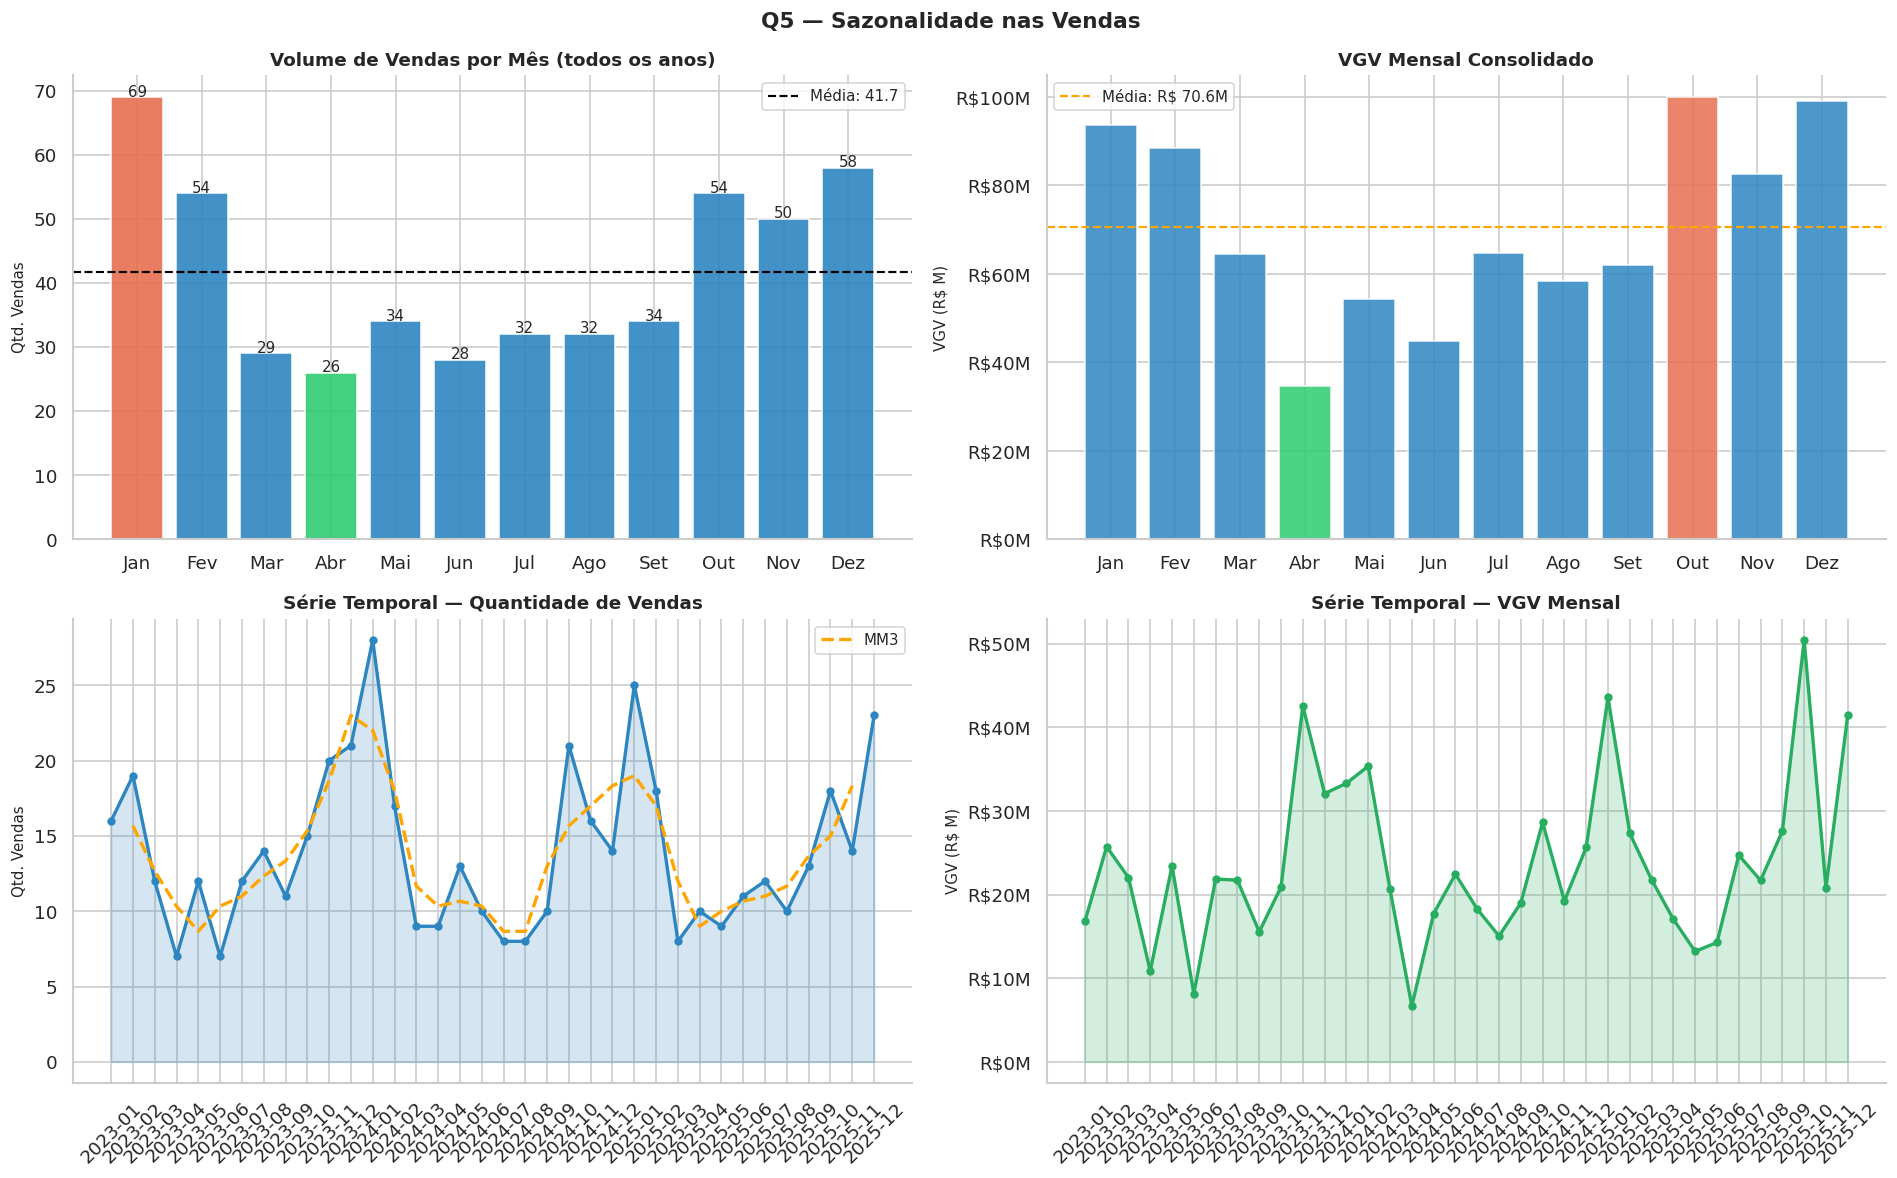

In [203]:
# %%
sazon = (
    df2.groupby("mes")
    .agg(
        qtd_vendas=("id_venda", "count"),
        vgv_total=("valor_venda", "sum"),
        ticket_mediano=("valor_venda", "median"),
        desc_medio=("desconto_pct", "mean"),
        dias_mediano=("dias_para_fechar", "median"),
    )
    .reset_index()
)
sazon["mes_label"] = sazon["mes"].map(MES_NOME)

sazon_mes_ano = (
    df2.assign(mes_ano=df2["data_venda"].dt.to_period("M"))
    .groupby("mes_ano")
    .agg(qtd_vendas=("id_venda", "count"), vgv_total=("valor_venda", "sum"))
    .reset_index()
)
sazon_mes_ano["mes_ano_str"] = sazon_mes_ano["mes_ano"].astype(str)

print("=== Sazonalidade (consolidado por mês) ===")
print(sazon[["mes_label", "qtd_vendas", "vgv_total", "dias_mediano"]]
      .rename(columns={"mes_label": "Mês", "qtd_vendas": "Vendas",
                       "vgv_total": "VGV", "dias_mediano": "Dias Mediano"})
      .to_string(index=False))

media_mensal = sazon["qtd_vendas"].mean()
sazon["indice_sazon"] = (sazon["qtd_vendas"] / media_mensal).round(2)
print("\n=== Índice de Sazonalidade (>1 = acima da média) ===")
print(sazon[["mes_label", "qtd_vendas", "indice_sazon"]]
      .sort_values("indice_sazon", ascending=False)
      .rename(columns={"mes_label": "Mês", "qtd_vendas": "Vendas",
                       "indice_sazon": "Índice"})
      .to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)

# Painel 1: Volume por mês (consolidado)
ax = axes[0, 0]
cores_bar = [
    "#E76F51" if v == sazon["qtd_vendas"].max() else
    "#2ECC71" if v == sazon["qtd_vendas"].min() else "#2E86C1"
    for v in sazon["qtd_vendas"]
]
bars = ax.bar(sazon["mes_label"], sazon["qtd_vendas"],
              color=cores_bar, edgecolor="white", alpha=0.9)
ax.axhline(media_mensal, color="black", linestyle="--", linewidth=1.3,
           label=f"Média: {media_mensal:.1f}")
for bar, val in zip(bars, sazon["qtd_vendas"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            str(int(val)), ha="center", fontsize=9)
ax.set_title("Volume de Vendas por Mês (todos os anos)")
ax.set_ylabel("Qtd. Vendas")
ax.legend(fontsize=9)

# Painel 2: VGV mensal consolidado
ax2 = axes[0, 1]

cores_vgv = [
    "#E76F51" if v == sazon["vgv_total"].max() else
    "#2ECC71" if v == sazon["vgv_total"].min() else "#2E86C1"
    for v in sazon["vgv_total"]
]

ax2.bar(sazon["mes_label"], sazon["vgv_total"] / 1e6,
        color=cores_vgv, edgecolor="white", alpha=0.85)
ax2.axhline(sazon["vgv_total"].mean() / 1e6, color="orange",
            linestyle="--", linewidth=1.3,
            label=f"Média: {fmt_moeda(sazon['vgv_total'].mean())}")
ax2.set_title("VGV Mensal Consolidado")
ax2.set_ylabel("VGV (R$ M)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R${v:.0f}M"))
ax2.legend(fontsize=9)

# Painel 3: Série temporal de vendas
ax3 = axes[1, 0]
x_str = sazon_mes_ano["mes_ano_str"]
ax3.fill_between(x_str, sazon_mes_ano["qtd_vendas"], alpha=0.2, color="#2E86C1")
ax3.plot(x_str, sazon_mes_ano["qtd_vendas"],
         color="#2E86C1", marker="o", markersize=4, linewidth=2)
mm3 = sazon_mes_ano["qtd_vendas"].rolling(3, center=True).mean()
ax3.plot(x_str, mm3, color="orange", linewidth=2, linestyle="--",
         label="MM3")
ax3.set_title("Série Temporal — Quantidade de Vendas")
ax3.set_ylabel("Qtd. Vendas")
ax3.tick_params(axis="x", rotation=45)
ax3.legend(fontsize=9)

# Painel 4: Série temporal VGV
ax4 = axes[1, 1]
ax4.fill_between(x_str, sazon_mes_ano["vgv_total"] / 1e6, alpha=0.2, color="#27AE60")
ax4.plot(x_str, sazon_mes_ano["vgv_total"] / 1e6,
         color="#27AE60", marker="o", markersize=4, linewidth=2)
ax4.set_title("Série Temporal — VGV Mensal")
ax4.set_ylabel("VGV (R$ M)")
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R${v:.0f}M"))
ax4.tick_params(axis="x", rotation=45)

fig.suptitle("Q5 — Sazonalidade nas Vendas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

* Há sazonalidade clara no volume de vendas, com picos em janeiro e no período de outubro a dezembro.

* Os meses de abril a setembro concentram os menores volumes de vendas.

* O padrão se repete ao longo dos três anos, indicando comportamento sazonal consistente.

* Uma análise mais robusta exigiria mais dados.

## 2.4. Visualização

### 2.4.1. Evolução mensal do VGV com breakdown por empreendimento

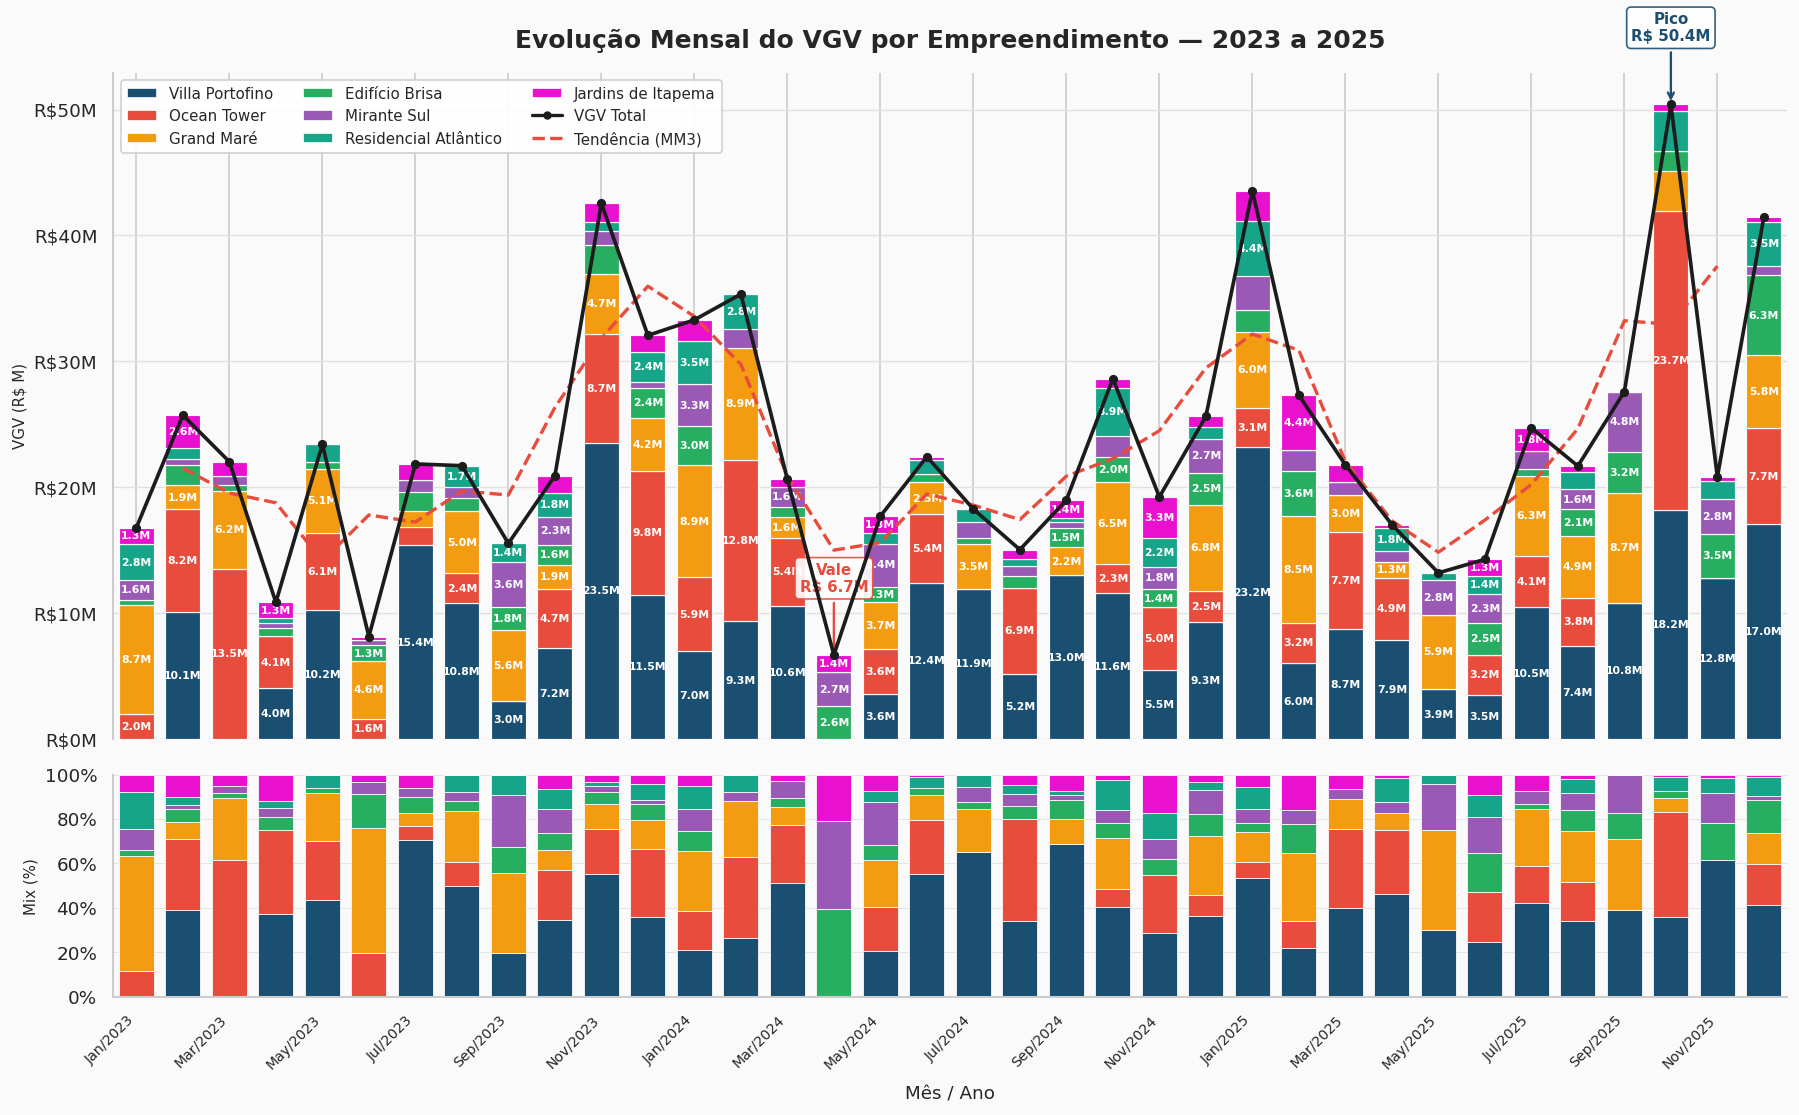

In [ ]:
# Preparação
vgv_pivot = (
    df2.assign(mes_ano_str=df2["data_venda"].dt.to_period("M")
                  .dt.to_timestamp().dt.strftime("%Y-%m"))
    .groupby(["mes_ano_str", "empreendimento"])["valor_venda"]
    .sum()
    .unstack(fill_value=0)
    / 1e6
)
vgv_pivot = vgv_pivot.sort_index()
vgv_pivot.index = pd.to_datetime(vgv_pivot.index).strftime("%b/%Y")

col_order   = vgv_pivot.sum().sort_values(ascending=False).index.tolist()
vgv_pivot   = vgv_pivot[col_order]
vgv_total   = vgv_pivot.sum(axis=1)
PALETTE_VGV = [
    "#1B4F72",  # Villa Portofino   — azul marinho
    "#E74C3C",  # Ocean Tower       — vermelho
    "#F39C12",  # Grand Maré        — laranja
    "#27AE60",  # Mirante Sul       — verde
    "#9B59B6",  # Edifício Brisa    — roxo
    "#17A589",  # Residencial Atlântico — verde-água
    "#E910CF",  # Jardins de Itapema — Rosa
]
x = np.arange(len(vgv_pivot))

fig = plt.figure(figsize=(18, 10), facecolor="#FAFAFA")
gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.08, figure=fig)
ax_main  = fig.add_subplot(gs[0])
ax_strip = fig.add_subplot(gs[1], sharex=ax_main)

# Barras empilhadas
bottoms = np.zeros(len(vgv_pivot))
for emp, color in zip(col_order, PALETTE_VGV):
    vals = vgv_pivot[emp].values
    ax_main.bar(x, vals, bottom=bottoms, color=color, edgecolor="#FAFAFA",
                linewidth=0.7, width=0.75, label=emp, zorder=3)
    for i, (bar_val, bot) in enumerate(zip(vals, bottoms)):
        frac = bar_val / (vgv_total.iloc[i] + 1e-9)
        if frac > 0.07:
            ax_main.text(x[i], bot + bar_val / 2, f"{bar_val:.1f}M",
                         ha="center", va="center",
                         fontsize=6.5, color="white", fontweight="bold")
    bottoms += vals

# Linha de total + MM3
ax_main.plot(x, vgv_total.values, color="#1C1C1C", linewidth=2.2,
             marker="o", markersize=4.5, zorder=5, label="VGV Total")
mm3 = pd.Series(vgv_total.values).rolling(3, center=True).mean()
ax_main.plot(x, mm3.values, color="#E74C3C", linewidth=2,
             linestyle="--", zorder=4, label="Tendência (MM3)")

# Pico e vale
peak_i   = int(vgv_total.argmax())
trough_i = int(vgv_total.argmin())
for idx, lbl, cor in [
    (peak_i,   f"Pico\n{fmt_moeda(vgv_total.iloc[peak_i]*1e6)}",   "#1B4F72"),
    (trough_i, f"Vale\n{fmt_moeda(vgv_total.iloc[trough_i]*1e6)}", "#E74C3C"),
]:
    ax_main.annotate(
        lbl, xy=(idx, vgv_total.iloc[idx]),
        xytext=(idx, vgv_total.iloc[idx] + vgv_total.max() * 0.1),
        fontsize=9, fontweight="bold", color=cor, ha="center",
        arrowprops=dict(arrowstyle="->", color=cor, lw=1.4),
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                  edgecolor=cor, alpha=0.9),
    )

ax_main.set_title("Evolução Mensal do VGV por Empreendimento — 2023 a 2025",
                  fontsize=15, fontweight="bold", pad=15)
ax_main.set_ylabel("VGV (R$ M)")
ax_main.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R${v:.0f}M"))
ax_main.set_xlim(-0.5, len(vgv_pivot) - 0.5)
ax_main.tick_params(labelbottom=False, bottom=False)
ax_main.set_facecolor("#FAFAFA")
ax_main.grid(axis="y", color="#E0E0E0", linewidth=0.8, zorder=0)
ax_main.spines["top"].set_visible(False)
ax_main.spines["bottom"].set_visible(False)

leg_handles = [mpatches.Patch(facecolor=c, label=e, edgecolor="white")
               for e, c in zip(col_order, PALETTE_VGV)]
leg_handles += [
    Line2D([0], [0], color="#1C1C1C", linewidth=2, marker="o", markersize=4, label="VGV Total"),
    Line2D([0], [0], color="#E74C3C", linewidth=2, linestyle="--", label="Tendência (MM3)"),
]
ax_main.legend(handles=leg_handles, loc="upper left", fontsize=9, ncol=3,
               framealpha=0.9, edgecolor="#CCCCCC")

# Painel de mix 100%
vgv_pct = vgv_pivot.div(vgv_pivot.sum(axis=1), axis=0) * 100
bottoms2 = np.zeros(len(vgv_pct))
for emp, color in zip(col_order, PALETTE_VGV):
    ax_strip.bar(x, vgv_pct[emp].values, bottom=bottoms2,
                 color=color, edgecolor="#FAFAFA", linewidth=0.5, width=0.75)
    bottoms2 += vgv_pct[emp].values

ax_strip.set_ylabel("Mix (%)", fontsize=9)
ax_strip.set_xlim(-0.5, len(vgv_pivot) - 0.5)
ax_strip.set_ylim(0, 100)
ax_strip.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax_strip.set_xticks(x[::2])
ax_strip.set_xticklabels(vgv_pivot.index[::2], rotation=45, ha="right", fontsize=8.5)
ax_strip.set_facecolor("#FAFAFA")
ax_strip.grid(axis="y", color="#E0E0E0", linewidth=0.5, zorder=0)
ax_strip.set_xlabel("Mês / Ano", fontsize=11, labelpad=8)
ax_strip.spines["top"].set_visible(False)

plt.tight_layout()
plt.show()


* O VGV mensal varia significativamente, com picos no começo e no final de 2025 e um vale acentuado em 2024.

* Villa Portofino é o principal gerador de receita e domina o VGV na maioria dos meses.

* Ocean Tower e Grand Maré aparecem como os segundos maiores contribuintes.

* A forte dependência de Villa Portofino cria risco de concentração no VGV total.


### 2.4.2. Quadrante de eficiência comercial por canal de origem

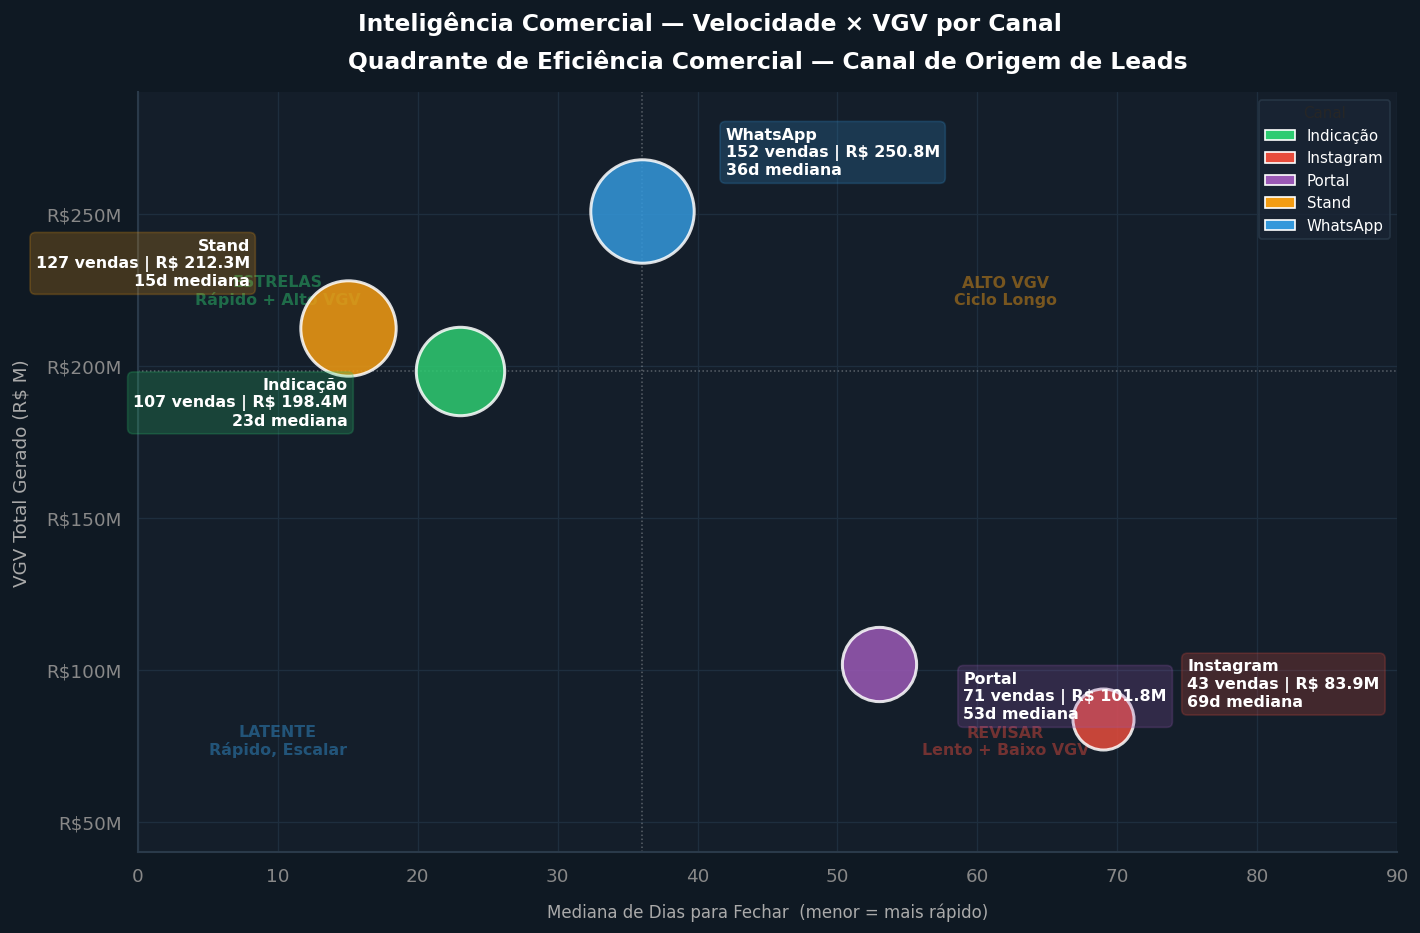

In [38]:
# %%
canal_agg = df2.groupby("origem_lead").agg(
    vgv=("valor_venda", "sum"),
    dias_med=("dias_para_fechar", "median"),
    qtd=("valor_venda", "count"),
    desconto=("desconto_pct", "mean"),
).reset_index()
canal_agg["vgv_m"] = canal_agg["vgv"] / 1e6

CANAL_CORES = {
    "Stand": "#F39C12", "Indicação": "#2ECC71",
    "WhatsApp": "#3498DB", "Portal": "#9B59B6", "Instagram": "#E74C3C",
}
OFFSETS = {
    "Stand": (-7, 14), "Indicação": (-8, -18),
    "WhatsApp": (6, 12), "Portal": (6, -18), "Instagram": (6, 4),
}

fig = plt.figure(figsize=(12, 8), facecolor="#0F1923")
ax  = fig.add_subplot(111)
ax.set_facecolor("#141E2A")

for _, row in canal_agg.iterrows():
    c  = CANAL_CORES.get(row["origem_lead"], "#AAAAAA")
    sz = (row["qtd"] / canal_agg["qtd"].max()) * 3500 + 350
    ax.scatter(row["dias_med"], row["vgv_m"], s=sz, color=c,
               alpha=0.85, edgecolors="white", linewidth=1.8, zorder=5)
    ox, oy = OFFSETS.get(row["origem_lead"], (4, 6))
    label  = (f"{row['origem_lead']}\n"
              f"{int(row['qtd'])} vendas | {fmt_moeda(row['vgv'])}\n"
              f"{row['dias_med']:.0f}d mediana")
    ax.annotate(
        label,
        xy=(row["dias_med"], row["vgv_m"]),
        xytext=(row["dias_med"] + ox, row["vgv_m"] + oy),
        fontsize=9.5, color="white", fontweight="bold",
        ha="right" if ox < 0 else "left",
        bbox=dict(boxstyle="round,pad=0.35", facecolor=c,
                  alpha=0.22, edgecolor=c, linewidth=1),
        zorder=6,
    )

x_mid = float(canal_agg["dias_med"].median())
y_mid = float(canal_agg["vgv_m"].median())
ax.axvline(x_mid, color="#FFF", linewidth=0.9, linestyle=":", alpha=0.3)
ax.axhline(y_mid, color="#FFF", linewidth=0.9, linestyle=":", alpha=0.3)

kw = dict(ha="center", fontsize=9.5, fontweight="bold", alpha=0.45)
ax.text(10,  220, "ESTRELAS\nRápido + Alto VGV",  color="#2ECC71", **kw)
ax.text(62,  220, "ALTO VGV\nCiclo Longo",         color="#F39C12", **kw)
ax.text(10,   72, "LATENTE\nRápido, Escalar",       color="#3498DB", **kw)
ax.text(62,   72, "REVISAR\nLento + Baixo VGV",     color="#E74C3C", **kw)

ax.set_xlabel("Mediana de Dias para Fechar  (menor = mais rápido)",
              fontsize=10, color="#AAAAAA", labelpad=10)
ax.set_ylabel("VGV Total Gerado (R$ M)", fontsize=11, color="#AAAAAA", labelpad=10)
ax.set_title("Quadrante de Eficiência Comercial — Canal de Origem de Leads",
             fontsize=14, fontweight="bold", color="white", pad=14)
ax.tick_params(colors="#888888")
for sp in ax.spines.values():
    sp.set_edgecolor("#2A3A4A")
ax.grid(color="#1E2E3E", linewidth=0.8, zorder=0)
ax.set_xlim(0, 90)
ax.set_ylim(40, 290)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R${v:.0f}M"))

leg_els = [mpatches.Patch(facecolor=CANAL_CORES[c], label=c)
           for c in canal_agg["origem_lead"]]
ax.legend(handles=leg_els, title="Canal", title_fontsize=9,
          labelcolor="white", facecolor="#1A2535", edgecolor="#2A3A4A",
          fontsize=9, loc="upper right")

fig.suptitle("Inteligência Comercial — Velocidade × VGV por Canal",
             fontsize=14, fontweight="bold", color="white", y=0.97)
plt.tight_layout()
plt.show()

* Stand e Indicação são os canais mais eficientes, combinando alto VGV com ciclos de fechamento rápidos.

* WhatsApp gera o maior volume de vendas e VGV, mas com ciclo de fechamento intermediário.

* Portal e Instagram apresentam ciclos mais longos e menor retorno relativo em VGV.

* A origem do lead é o principal fator que diferencia a eficiência comercial entre os canais.

# 3.0.  SQL — RANKING DE IMOBILIÁRIAS PARCEIRAS

In [206]:
df3 = df2.copy()

In [229]:
# ============================================================
# 3A.1 — CARREGAR DADOS NO SQLite IN-MEMORY
# ============================================================

con = sqlite3.connect(':memory:')
df.to_sql('vendas', con, index=False, if_exists='replace')

500

In [230]:
SQL_RANKING = """
WITH base AS (
    SELECT
        imobiliaria,

        COUNT(*)                                            AS total_vendas,
        SUM(valor_venda)                                    AS vgv_total,
        AVG(valor_venda)                                    AS ticket_medio,

        -- Fórmula: (Σ tabela - Σ venda) / Σ tabela * 100
        (1.0 - SUM(valor_venda) / NULLIF(SUM(valor_tabela), 0))
            * 100                                           AS desconto_medio_pct,

        SUM(valor_venda * comissao_pct / 100.0)             AS comissao_total,
        AVG(dias_para_fechar)                               AS dias_medio_fechamento

    FROM  vendas
    GROUP BY imobiliaria
),

totais AS (
    SELECT SUM(vgv_total) AS vgv_global FROM base
)

SELECT
    ROW_NUMBER() OVER (ORDER BY b.vgv_total DESC)       AS ranking,
    b.imobiliaria,
    ROUND(b.vgv_total,                              2)  AS vgv_total,
    b.total_vendas,
    ROUND(b.vgv_total * 100.0 / t.vgv_global,      2)  AS share_vgv_pct,
    ROUND(b.ticket_medio,                           2)  AS ticket_medio,
    ROUND(b.desconto_medio_pct,                     2)  AS desconto_medio_pct,
    ROUND(b.comissao_total,                         2)  AS comissao_total,
    ROUND(b.dias_medio_fechamento,                  1)  AS dias_medio_fechamento

FROM  base b
CROSS JOIN totais t          
ORDER BY b.vgv_total DESC
"""

ranking_sql = pd.read_sql_query(SQL_RANKING, con)
con.close()

# Exibição formatada
disp = ranking_sql.copy()
disp["vgv_total"]             = disp["vgv_total"].apply(fmt_moeda)
disp["ticket_medio"]          = disp["ticket_medio"].apply(fmt_moeda)
disp["comissao_total"]        = disp["comissao_total"].apply(fmt_moeda)
disp["desconto_medio_pct"]    = disp["desconto_medio_pct"].apply(lambda v: f"{v:.2f}%")
disp["share_vgv_pct"]         = disp["share_vgv_pct"].apply(lambda v: f"{v:.2f}%")
disp["dias_medio_fechamento"] = disp["dias_medio_fechamento"].apply(lambda v: f"{v:.1f}d")
disp.columns = [
    "#", "Imobiliária", "VGV Total", "Vendas",  "Share %",
    "Ticket Médio", "Desconto Médio", "Comissão Total", "Ciclo Médio",
]
print(disp.to_string(index=False))


 #           Imobiliária VGV Total  Vendas Share % Ticket Médio Desconto Médio Comissão Total Ciclo Médio
 1     Atlântica Imóveis R$ 109.0M      48  12.86%      R$ 2.3M          3.19%        R$ 5.8M       34.3d
 2    Oceano Imobiliária R$ 102.7M      59  12.12%      R$ 1.7M          3.68%        R$ 5.4M       33.9d
 3          Prime Realty  R$ 97.7M      50  11.53%      R$ 2.0M          3.77%        R$ 5.1M       34.9d
 4 Costa Sul Imobiliária  R$ 94.9M      61  11.21%      R$ 1.6M          3.08%        R$ 5.0M       28.2d
 5             Viva Imob  R$ 94.8M      56  11.19%      R$ 1.7M          4.02%        R$ 5.0M       32.3d
 6           Ponto Nobre  R$ 84.0M      50   9.91%      R$ 1.7M          4.08%        R$ 4.5M       34.5d
 7   Sul Brasil Negócios  R$ 78.3M      52   9.25%      R$ 1.5M          4.25%        R$ 4.2M       35.7d
 8   Direto com Corretor  R$ 67.6M      39   7.98%      R$ 1.7M          2.63%        R$ 2.5M       37.0d
 9       Litoral Imóveis  R$ 67.0M      44   7

# 4.0. ENGENHARIA DE ATRIBUTOS

In [47]:
df4 = df3.copy()

In [48]:
# Encoding ciclico do mes 
df4['mes_sin'] = np.sin(2 * np.pi * df4['mes'] / 12)
df4['mes_cos'] = np.cos(2 * np.pi * df4['mes'] / 12)
df4['tri_sin'] = np.sin(2 * np.pi * df4['trimestre'] / 4)
df4['tri_cos'] = np.cos(2 * np.pi * df4['trimestre'] / 4)

In [ ]:
df4["valor_log"] = np.log1p(df4["valor_tabela"])  

# 5.0. DATA PREPARATION

In [50]:
df5 = df4.copy()

## 5.1. Train/test split


In [51]:
SPLIT_IDX = int(len(df5) * TRAIN_SIZE)

X_all = df5.copy()
y_all = df5[TARGET].copy()

# Conjuntos de treino e teste (splits temporais, não aleatórios)
train_raw = df5.iloc[:SPLIT_IDX].copy()
test_raw  = df5.iloc[SPLIT_IDX:].copy()
y_train   = train_raw[TARGET].copy()
y_test    = test_raw[TARGET].copy()

print(f"Treino : {len(train_raw)} amostras | "
      f"{train_raw['data_venda'].min().date()} → {train_raw['data_venda'].max().date()}")
print(f"Teste  : {len(test_raw)}  amostras | "
      f"{test_raw['data_venda'].min().date()} → {test_raw['data_venda'].max().date()}")

Treino : 400 amostras | 2023-01-03 → 2025-06-01
Teste  : 100  amostras | 2025-06-03 → 2025-12-28


## 5.2. Baseline

In [52]:
# Baseline 1 — média global 
b1_pred = np.full(len(y_test), y_train.mean())
mae_b1  = mean_absolute_error(y_test, b1_pred)
mse_b1  = mean_squared_error(y_test, b1_pred)
rmse_b1 = np.sqrt(mse_b1)

# Baseline 2 — média por canal - prediz a média histórica de  `dias_para_fechar` do canal de origem do lead.
canal_means = (
    df5.iloc[:SPLIT_IDX]
    .groupby("origem_lead")["dias_para_fechar"]
    .mean()
)
b2_pred = test_raw["origem_lead"].map(canal_means).fillna(y_train.mean()).values
mae_b2  = mean_absolute_error(y_test, b2_pred)
mse_b2  = mean_squared_error(y_test, b2_pred)
rmse_b2 = np.sqrt(mse_b2)
r2_b2   = r2_score(y_test, b2_pred)

print(f"{'':25} {'MAE':>8}  {'RMSE':>8}  {'MSE':>10}  {'R²':>8}")
print("─" * 65)
print(f"Baseline 1 (média global)  {mae_b1:>7.2f}d  {rmse_b1:>7.2f}d  {mse_b1:>9.2f}  {'—':>8}")
print(f"Baseline 2 (média/canal)   {mae_b2:>7.2f}d  {rmse_b2:>7.2f}d  {mse_b2:>9.2f}  {r2_b2:>8.4f}")

                               MAE      RMSE         MSE        R²
─────────────────────────────────────────────────────────────────
Baseline 1 (média global)    17.92d    22.53d     507.66         —
Baseline 2 (média/canal)      9.99d    13.79d     190.11    0.6255


## 5.3. Encoding

### 5.3.1. Ordinal Encoding

In [62]:
# Ordinal Encoding

TIPOLOGIA_RANK = {
    "Studio":    1,
    "1 Quarto":  2,
    "2 Quartos": 3,
    "3 Quartos": 4,
    "Cobertura": 5,
}
train_raw["tipologia_ord"] = train_raw["tipologia"].map(TIPOLOGIA_RANK)
test_raw["tipologia_ord"]  = test_raw["tipologia"].map(TIPOLOGIA_RANK)

### 5.3.2. One Hot Encoding

In [63]:
# Origem Lead
ohe_train = pd.get_dummies(
    train_raw["origem_lead"], prefix="canal", drop_first=True, dtype=float
)
ohe_test = pd.get_dummies(
    test_raw["origem_lead"], prefix="canal", drop_first=True, dtype=float
)

# Alinha colunas: categorias ausentes no teste recebem 0
ohe_test = ohe_test.reindex(columns=ohe_train.columns, fill_value=0.0)
OHE_COLS = list(ohe_train.columns)

In [64]:
# Empreendimento
ohe_emp_train = pd.get_dummies(
    train_raw["empreendimento"], prefix="emp", drop_first=True, dtype=float
)
ohe_emp_test = pd.get_dummies(
    test_raw["empreendimento"], prefix="emp", drop_first=True, dtype=float
)
ohe_emp_test = ohe_emp_test.reindex(columns=ohe_emp_train.columns, fill_value=0.0)

OHE_EMP_COLS = list(ohe_emp_train.columns)

### 5.3.3. Smoothed Target Encoding

In [237]:
df.columns

Index(['id_venda', 'data_venda', 'empreendimento', 'cidade', 'tipologia',
       'area_m2', 'valor_tabela', 'valor_venda', 'forma_pagamento', 'corretor',
       'imobiliaria', 'origem_lead', 'dias_para_fechar', 'comissao_pct'],
      dtype='object')

In [ ]:
# Corretor e Imobiliaria
CAT_TE_COLS = [
    "corretor",
    "imobiliaria",
]
for col in CAT_TE_COLS:
    tr_enc, te_enc = smoothed_target_encode(train_raw, test_raw, col)
    train_raw[f"te_{col}"] = tr_enc
    test_raw[f"te_{col}"]  = te_enc

TE_COLS = [f"te_{c}" for c in CAT_TE_COLS]

In [66]:
# ── 4. Consolidação 

ALL_OHE_COLS = OHE_COLS +  OHE_EMP_COLS  # OHE_COLS = canal_* de origem_lead
NUM_COLS = ["area_m2", "valor_log", "ano", "mes_sin", "mes_cos", "tri_sin", "tri_cos"]

ALL_FEATS = NUM_COLS + ["tipologia_ord"] + ALL_OHE_COLS + TE_COLS

X_train = pd.concat(
    [
        train_raw[NUM_COLS + ["tipologia_ord"] + TE_COLS].reset_index(drop=True),
        ohe_train.reset_index(drop=True),
        ohe_emp_train.reset_index(drop=True),
    ],
    axis=1,
)[ALL_FEATS]

X_test = pd.concat(
    [
        test_raw[NUM_COLS + ["tipologia_ord"] + TE_COLS].reset_index(drop=True),
        ohe_test.reset_index(drop=True),
        ohe_emp_test.reset_index(drop=True),
    ],
    axis=1,
)[ALL_FEATS]

In [236]:
X_train.columns

Index(['area_m2', 'valor_log', 'ano', 'mes_sin', 'mes_cos', 'tri_sin',
       'tri_cos', 'tipologia_ord', 'canal_Instagram', 'canal_Portal',
       'canal_Stand', 'canal_WhatsApp', 'emp_Grand Maré',
       'emp_Jardins de Itapema', 'emp_Mirante Sul', 'emp_Ocean Tower',
       'emp_Residencial Atlântico', 'emp_Villa Portofino', 'te_corretor',
       'te_imobiliaria'],
      dtype='object')

## 5.4. Rescalling

Cada grupo de features recebe o scaler mais adequado à sua distribuição:

| Scaler | Features | Justificativa |
|---|---|---|
| RobustScaler | area_m2, valor_log | Outliers confirmados nos boxplots; mediana/IQR são mais robustos |
| StandardScaler | te_corretor, te_imobiliaria | Distribuição simétrica pós-smoothing; necessário para regularização equilibrada nos modelos lineares |
| MinMaxScaler | ano, tipologia_ord | Range fixo e conhecido; preserva ordenação em [0,1] |
| Passthrough | OHE (canal/emp), sin/cos | Já em escala adequada por construção (0/1 e [-1,1]) |

In [ ]:
ROBUST_COLS      = ["area_m2", "valor_log"]    
STANDARD_COLS    = TE_COLS                     # em escala de dias → z-score uniformiza
MINMAX_COLS      = ["ano", "tipologia_ord"]    # range curto e fixo → [0, 1]
PASSTHROUGH_COLS = (                           # já em escala adequada
    ["mes_sin", "mes_cos", "tri_sin", "tri_cos"]
    + ALL_OHE_COLS                             # canal_* + fp_* + emp_* → já são 0/1
)

scaler = ColumnTransformer(
    transformers=[
        ("robust",      RobustScaler(),   ROBUST_COLS),
        ("standard",    StandardScaler(), STANDARD_COLS),
        ("minmax",      MinMaxScaler(),   MINMAX_COLS),
        ("passthrough", "passthrough",    PASSTHROUGH_COLS),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=scaler.get_feature_names_out(),
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=scaler.get_feature_names_out(),
)

In [ ]:
print(f"  {'RobustScaler  '} ({len(ROBUST_COLS):2d}): {ROBUST_COLS}")
print(f"  {'StandardScaler'} ({len(STANDARD_COLS):2d}): {STANDARD_COLS}")
print(f"  {'MinMaxScaler  '} ({len(MINMAX_COLS):2d}): {MINMAX_COLS}")
print(f"  {'passthrough   '} ({len(PASSTHROUGH_COLS):2d}): {PASSTHROUGH_COLS}")
print(f"\n  Shape final → treino: {X_train_scaled.shape} | teste: {X_test_scaled.shape}")

  RobustScaler   ( 2): ['area_m2', 'valor_log']
  StandardScaler ( 2): ['te_corretor', 'te_imobiliaria']
  MinMaxScaler   ( 2): ['ano', 'tipologia_ord']
  passthrough    (14): ['mes_sin', 'mes_cos', 'tri_sin', 'tri_cos', 'canal_Instagram', 'canal_Portal', 'canal_Stand', 'canal_WhatsApp', 'emp_Grand Maré', 'emp_Jardins de Itapema', 'emp_Mirante Sul', 'emp_Ocean Tower', 'emp_Residencial Atlântico', 'emp_Villa Portofino']

  Shape final → treino: (400, 20) | teste: (100, 20)


**Features descartadas:**

* Cidade -> colinearidade com empreendimento

* valor_venda, desconto_pct -> Data leakage. Valor só é possivel após a venda. Não tem sentido colocar como preditivo. 

* id_venda, comisssao_pct -> Nao carrega informação preditiva

* data_venda -> substituida pelas features derivadas

# 6.0. MACHINE LEARNING MODELING

## 6.1. Ridge

In [116]:
# model definition
ridge_model = Ridge(alpha=1.0)

# model training
ridge_model.fit(X_train_scaled, y_train)

# prediction
yhat_ridge = np.clip(ridge_model.predict(X_test_scaled), 0, None)

## 6.2. Lasso

In [117]:
# model definition
lasso_model = Lasso(alpha=0.01, max_iter=10_000)

# model training
lasso_model.fit(X_train_scaled, y_train)

# prediction
yhat_lasso = np.clip(lasso_model.predict(X_test_scaled), 0, None)

## 6.3. QuantileRegressor

In [119]:
# %%
# model definition
qr_model = QuantileRegressor(quantile=0.5, alpha=0.001, solver="highs")

# model training
qr_model.fit(X_train_scaled, y_train)

# prediction
yhat_qr = np.clip(qr_model.predict(X_test_scaled), 0, None)

## 6.4. Random Forest

In [121]:
# model definition
rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=5, min_samples_leaf=8,
    random_state=RANDOM_STATE, n_jobs=-1,
)

# model training
rf_model.fit(X_train_scaled, y_train)

# prediction
yhat_rf = np.clip(rf_model.predict(X_test_scaled), 0, None)

## 6.5. Extra Trees

In [122]:
# model definition
et_model = ExtraTreesRegressor(
    n_estimators=200, max_depth=5, min_samples_leaf=8,
    random_state=RANDOM_STATE, n_jobs=-1,
)

# model training
et_model.fit(X_train_scaled, y_train)

# prediction
yhat_et = np.clip(et_model.predict(X_test_scaled), 0, None)

## 6.6. Gradient Boosting

In [123]:
# model definition
gb_model = GradientBoostingRegressor(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    min_samples_leaf=8, random_state=RANDOM_STATE,
)

# model training
gb_model.fit(X_train_scaled, y_train)

# prediction
yhat_gb = np.clip(gb_model.predict(X_test_scaled), 0, None)

## 6.7. LightGBM

In [124]:
# model definition
lgb_model = lgb.LGBMRegressor(
    objective="regression_l1", n_estimators=300, num_leaves=15,
    learning_rate=0.05, min_child_samples=10,
    random_state=RANDOM_STATE, verbose=-1,
)

# model training
lgb_model.fit(X_train_scaled, y_train)

# prediction
yhat_lgb = np.clip(lgb_model.predict(X_test_scaled), 0, None)

## 6.8. XGBoost

In [125]:
# model definition
xgb_model = xgb.XGBRegressor(
    objective="reg:absoluteerror", n_estimators=300, max_depth=3,
    learning_rate=0.05, min_child_weight=5,
    random_state=RANDOM_STATE, verbosity=0,
)

# model training
xgb_model.fit(X_train_scaled, y_train)

# prediction
yhat_xgb = np.clip(xgb_model.predict(X_test_scaled), 0, None)

# 7.0. MÉTRICAS DE PERFORMANCE

In [215]:
# ── Avaliação de todos os modelos ─────────────────────────────────────────────
models_results = [
    ("Baseline2 Canal Mean",  b2_pred),
    ("Ridge",                yhat_ridge),
    ("Lasso",                yhat_lasso),
    ("QuantileReg",          yhat_qr),
    ("ExtraTrees",           yhat_et),
    ("RandomForest",         yhat_rf),
    ("GradientBoosting",     yhat_gb),
    ("LightGBM",             yhat_lgb),
    ("XGBoost",              yhat_xgb),
]

results_df = pd.DataFrame()

for model_name, predictions in models_results:
    result = regression_metrics(model_name, y_test, predictions, baseline_mae=mae_b2)
    results_df = pd.concat([results_df, result], ignore_index=True)

results_df = results_df.sort_values("MAE").reset_index(drop=True)
results_df

,Model,MAE,RMSE,MSE,R²,vs_Baseline2
0,QuantileReg,9.849,14.223,202.281,0.6015,0.141
1,ExtraTrees,9.950,14.017,196.476,0.6130,0.040
2,Baseline2 Canal Mean,9.990,13.788,190.107,0.6255,-0.000
3,Lasso,10.161,14.302,204.533,0.5971,-0.172
4,RandomForest,10.210,14.373,206.572,0.5931,-0.220
5,Ridge,10.267,14.417,207.841,0.5906,-0.277
6,GradientBoosting,10.380,14.547,211.609,0.5832,-0.390
7,XGBoost,10.566,14.896,221.886,0.5629,-0.576
8,LightGBM,10.786,15.135,229.062,0.5488,-0.796


* MAE foi escolhido como métrica principal porque mede diretamente o erro médio em dias, tornando a interpretação simples e alinhada ao problema de negócio.

* MSE e RMSE não são ideais pois penalizam erros grandes de forma quadrática, o que faria poucos casos extremos dominarem a avaliação do modelo.

* Como dias_para_fechar possui distribuição assimétrica com outliers naturais, o MAE é mais robusto e representa melhor o erro típico das previsões.

# 8.0. AJUSTE DE HIPERPARAMETROS

In [238]:
N_OPT_TRAIN = int(len(X_train_scaled) * 0.8)   # 320 amostras

X_opt_train = X_train_scaled.iloc[:N_OPT_TRAIN]
X_opt_val   = X_train_scaled.iloc[N_OPT_TRAIN:]
y_opt_train = y_train.iloc[:N_OPT_TRAIN]
y_opt_val   = y_train.iloc[N_OPT_TRAIN:]

N_TRIALS = 500

# ── Função auxiliar de avaliação no holdout ──────────────────────────────────
def holdout_mae(model) -> float:
    """Treina no opt_train, avalia no opt_val. Retorna MAE."""
    model.fit(X_opt_train, y_opt_train)
    pred = np.clip(model.predict(X_opt_val), 0, None)
    return mean_absolute_error(y_opt_val, pred)

## 8.1. QuantileRegressor

In [239]:
def objective_qr(trial: optuna.Trial) -> float:
    model = QuantileRegressor(
        quantile = 0.5,
        alpha    = trial.suggest_float("alpha", 1e-5, 0.05, log=True),
        solver   = "highs",
    )
    return holdout_mae(model)


optuna.logging.set_verbosity(optuna.logging.WARNING)
study_qr = optuna.create_study(direction="minimize", study_name="QuantileReg")
study_qr.optimize(objective_qr, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n  Melhor MAE : {study_qr.best_value:.3f}d")
print(f"  Melhores parâmetros:")
for k, v in study_qr.best_params.items():
    print(f"    {k}: {v}")

Best trial: 4. Best value: 10.1753: 100%|██████████| 500/500 [00:10<00:00, 49.19it/s]


  Melhor MAE : 10.175d
  Melhores parâmetros:
    alpha: 0.0005926037717659955


## 8.2. Extra Trees

In [249]:
def objective_et(trial: optuna.Trial) -> float:
    model = ExtraTreesRegressor(
        n_estimators      = trial.suggest_int("n_estimators", 100, 600),
        max_depth         = trial.suggest_int("max_depth", 3, 6),         
        min_samples_leaf  = trial.suggest_int("min_samples_leaf", 6, 30),
        min_samples_split = trial.suggest_int("min_samples_split", 4, 20),
        max_features      = trial.suggest_float("max_features", 0.3, 1.0),
        bootstrap         = trial.suggest_categorical("bootstrap", [True, False]),
        random_state      = RANDOM_STATE,
        n_jobs            = -1,
    )
    return holdout_mae(model)


study_et = optuna.create_study(direction="minimize", study_name="ExtraTrees")
study_et.optimize(objective_et, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n  Melhor  MAE : {study_et.best_value:.3f}d")
print(f"  Melhores parâmetros:")
for k, v in study_et.best_params.items():
    print(f"    {k}: {v}")

Best trial: 467. Best value: 10.4873: 100%|██████████| 500/500 [02:27<00:00,  3.38it/s]


  Melhor  MAE : 10.487d
  Melhores parâmetros:
    n_estimators: 184
    max_depth: 5
    min_samples_leaf: 12
    min_samples_split: 12
    max_features: 0.6979122740239849
    bootstrap: False


## 8.3. Random Forest

In [250]:
def objective_rf(trial: optuna.Trial) -> float:
    model = RandomForestRegressor(
        n_estimators      = trial.suggest_int("n_estimators", 100, 600),
        max_depth         = trial.suggest_int("max_depth", 3, 7),
        min_samples_leaf  = trial.suggest_int("min_samples_leaf", 6, 30),
        min_samples_split = trial.suggest_int("min_samples_split", 4, 20),
        max_features      = trial.suggest_float("max_features", 0.3, 1.0),
        random_state      = RANDOM_STATE,
        n_jobs            = -1,
    )
    return holdout_mae(model)


study_rf = optuna.create_study(direction="minimize", study_name="RandomForest")
study_rf.optimize(objective_rf, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n  Melhor MAE : {study_rf.best_value:.3f}d")
print(f"  Melhores parâmetros:")
for k, v in study_rf.best_params.items():
    print(f"    {k}: {v}")

Best trial: 218. Best value: 10.6358: 100%|██████████| 500/500 [01:38<00:00,  5.10it/s]


  Melhor MAE : 10.636d
  Melhores parâmetros:
    n_estimators: 152
    max_depth: 4
    min_samples_leaf: 13
    min_samples_split: 5
    max_features: 0.9770158498637254


## 8.4. Gradient Boosting

In [251]:
def objective_gb(trial: optuna.Trial) -> float:
    model = GradientBoostingRegressor(
        n_estimators      = trial.suggest_int("n_estimators", 100, 600),
        max_depth         = trial.suggest_int("max_depth", 2,7),        
        learning_rate     = trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        min_samples_leaf  = trial.suggest_int("min_samples_leaf", 6, 30),
        min_samples_split = trial.suggest_int("min_samples_split", 4, 20),
        subsample         = trial.suggest_float("subsample", 0.6, 1.0),  
        max_features      = trial.suggest_float("max_features", 0.3, 1.0),
        random_state      = RANDOM_STATE,
    )
    return holdout_mae(model)


study_gb = optuna.create_study(direction="minimize", study_name="GradientBoosting")
study_gb.optimize(objective_gb, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n  Melhor MAE : {study_gb.best_value:.3f}d")
print(f"  Melhores parâmetros:")
for k, v in study_gb.best_params.items():
    print(f"    {k}: {v}")

Best trial: 394. Best value: 10.7553: 100%|██████████| 500/500 [01:16<00:00,  6.54it/s]


  Melhor MAE : 10.755d
  Melhores parâmetros:
    n_estimators: 226
    max_depth: 4
    learning_rate: 0.011010669194209843
    min_samples_leaf: 16
    min_samples_split: 13
    subsample: 0.988145638990393
    max_features: 0.810153632308407


## 8.5. Modelos Finais com Melhores Hiperparâmetros

In [252]:
# Quantile Regressor

# model definition
qr_tuned = QuantileRegressor(**study_qr.best_params, quantile=0.5, solver="highs")

# model training — usa os 400 completos, não apenas os 320 do Optuna
qr_tuned.fit(X_train_scaled, y_train)

# prediction
yhat_qr_tuned = np.clip(qr_tuned.predict(X_test_scaled), 0, None)

In [253]:
# Extra Trees

# model definition
et_tuned = ExtraTreesRegressor(**study_et.best_params, random_state=RANDOM_STATE, n_jobs=-1)

# model training
et_tuned.fit(X_train_scaled, y_train)

# prediction
yhat_et_tuned = np.clip(et_tuned.predict(X_test_scaled), 0, None)

In [254]:
# Random Forest 

# model definition
rf_tuned = RandomForestRegressor(**study_rf.best_params, random_state=RANDOM_STATE, n_jobs=-1)

# model training
rf_tuned.fit(X_train_scaled, y_train)

# prediction
yhat_rf_tuned = np.clip(rf_tuned.predict(X_test_scaled), 0, None)

In [255]:
# G. Boosting 

# model definition
gb_tuned = GradientBoostingRegressor(**study_gb.best_params, random_state=RANDOM_STATE)

# model training
gb_tuned.fit(X_train_scaled, y_train)

# prediction
yhat_gb_tuned = np.clip(gb_tuned.predict(X_test_scaled), 0, None)

In [256]:
# %%
models_comparison = [
    ("Baseline2_CanalMean",      b2_pred),
    ("QuantileReg_default",      yhat_qr),
    ("QuantileReg_tuned",        yhat_qr_tuned),
    ("ExtraTrees_default",       yhat_et),
    ("ExtraTrees_tuned",         yhat_et_tuned),
    ("RandomForest_default",     yhat_rf),
    ("RandomForest_tuned",       yhat_rf_tuned),
    ("GradientBoosting_default", yhat_gb),
    ("GradientBoosting_tuned",   yhat_gb_tuned),
]

results_comparison = pd.DataFrame()
for model_name, predictions in models_comparison:
    result = regression_metrics(model_name, y_test, predictions, baseline_mae=mae_b2)
    results_comparison = pd.concat([results_comparison, result], ignore_index=True)

results_comparison = results_comparison.sort_values("MAE").reset_index(drop=True)
results_comparison

,Model,MAE,RMSE,MSE,R²,vs_Baseline2
0,QuantileReg_tuned,9.847,14.221,202.233,0.6016,0.143
1,QuantileReg_default,9.849,14.223,202.281,0.6015,0.141
2,ExtraTrees_default,9.950,14.017,196.476,0.6130,0.040
3,ExtraTrees_tuned,9.960,13.964,195.005,0.6159,0.029
4,Baseline2_CanalMean,9.990,13.788,190.107,0.6255,-0.000
5,RandomForest_tuned,10.087,13.887,192.848,0.6201,-0.097
6,GradientBoosting_tuned,10.158,14.079,198.204,0.6096,-0.168
7,RandomForest_default,10.210,14.373,206.572,0.5931,-0.220
8,GradientBoosting_default,10.380,14.547,211.609,0.5832,-0.390


# 9.0. MODELO FINAL

In [257]:
yhat     = np.clip(qr_tuned.predict(X_test_scaled), 0, None)
residuos = y_test.values - yhat

## 9.1. Resumo de Performance

In [ ]:
residuos   = y_test.values - yhat
mae_qr     = mean_absolute_error(y_test, yhat)
rmse_qr    = np.sqrt(mean_squared_error(y_test, yhat))
r2_qr      = r2_score(y_test, yhat)
mape_qr    = np.mean(np.abs(residuos / y_test.values)) * 100

print("=" * 60)
print("  MODELO FINAL — QuantileRegressor(q=0.5, α=0.001)")
print("=" * 60)
print(f"""
  Métricas no conjunto de teste (n={len(y_test)}):
  
  MAE   = {mae_qr:.3f}d                      
  RMSE  = {rmse_qr:.3f}d                     
  R²    = {r2_qr:.4f}                        
""")
print("=" * 60)

  MODELO FINAL — QuantileRegressor(q=0.5, α=0.001)

  Métricas no conjunto de teste (n=100):

  MAE   = 9.847d                      
  RMSE  = 14.221d                     
  R²    = 0.6016                        
  MAPE  = 86.7%                     



* O modelo erra, em média, ~10 dias ao estimar o tempo de fechamento de uma venda.

* O modelo explica ~60% da variância dos dias para fechar. 

* O dataset tem baixo poder preditivo além do canal de origem. O modelo não é inútil — ele aprende a diferença dentro de cada canal. Mas o ganho marginal sobre um baseline simples é modesto, o que há um teto informacional real. 

* Para melhorar, precisa de features de CRM.

## 9.2. Predito vs. Real

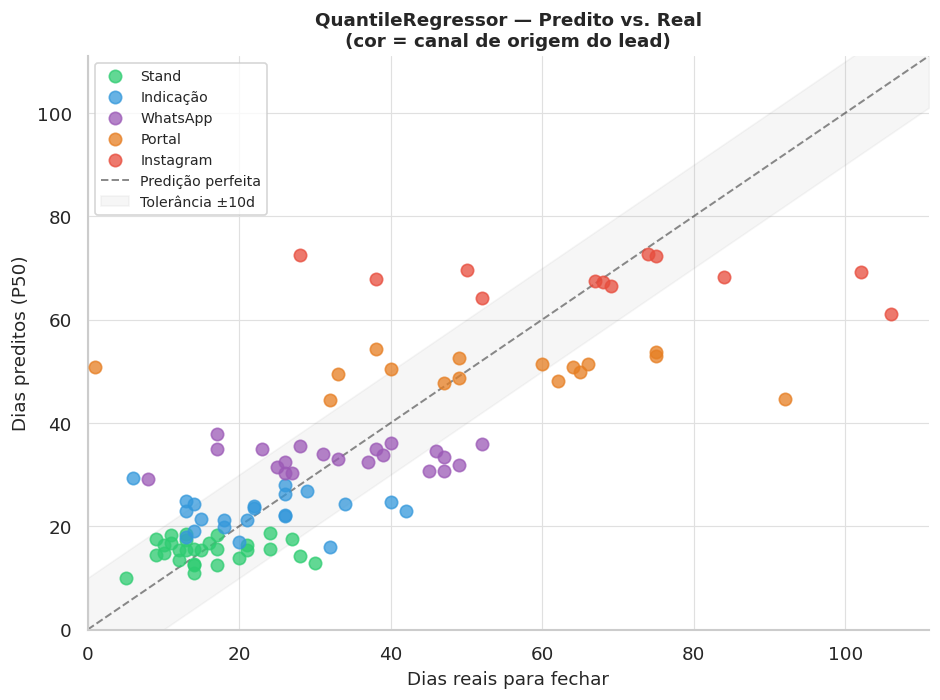

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

cores_canal = {
    "Stand":     "#2ECC71",
    "Indicação": "#3498DB",
    "WhatsApp":  "#9B59B6",
    "Portal":    "#E67E22",
    "Instagram": "#E74C3C",
}

for canal, cor in cores_canal.items():
    mask = test_raw["origem_lead"].values == canal
    if mask.sum() == 0: continue
    ax.scatter(y_test.values[mask], yhat[mask],
               color=cor, alpha=0.75, s=55, label=canal, zorder=3)

lim = max(y_test.max(), yhat.max()) + 5
ax.plot([0, lim], [0, lim], "k--", linewidth=1.2, alpha=0.5, label="Predição perfeita")
ax.fill_between([0, lim], [0-10, lim-10], [0+10, lim+10],
                alpha=0.07, color="gray", label="Tolerância ±10d")

ax.set_xlabel("Dias reais para fechar", fontsize=11)
ax.set_ylabel("Dias preditos (P50)", fontsize=11)
ax.set_title("QuantileRegressor — Predito vs. Real\n(cor = canal de origem do lead)",
             fontweight="bold")
ax.legend(fontsize=8.5, loc="upper left")
ax.grid(color="#E0E0E0", linewidth=0.7)
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)

plt.tight_layout()
plt.show()

O modelo funciona bem para canais com comportamento previsível (Stand, Indicação), mas enfrenta limitações estruturais em canais digitais (Instagram, Portal), onde a variância intrínseca do lead não está capturada pelas features disponíveis. Isso é um argumento direto para enriquecer o dataset com dados de CRM — número de interações, tempo de resposta e histórico de visitas.


## 9.3. Análise de Resíduos

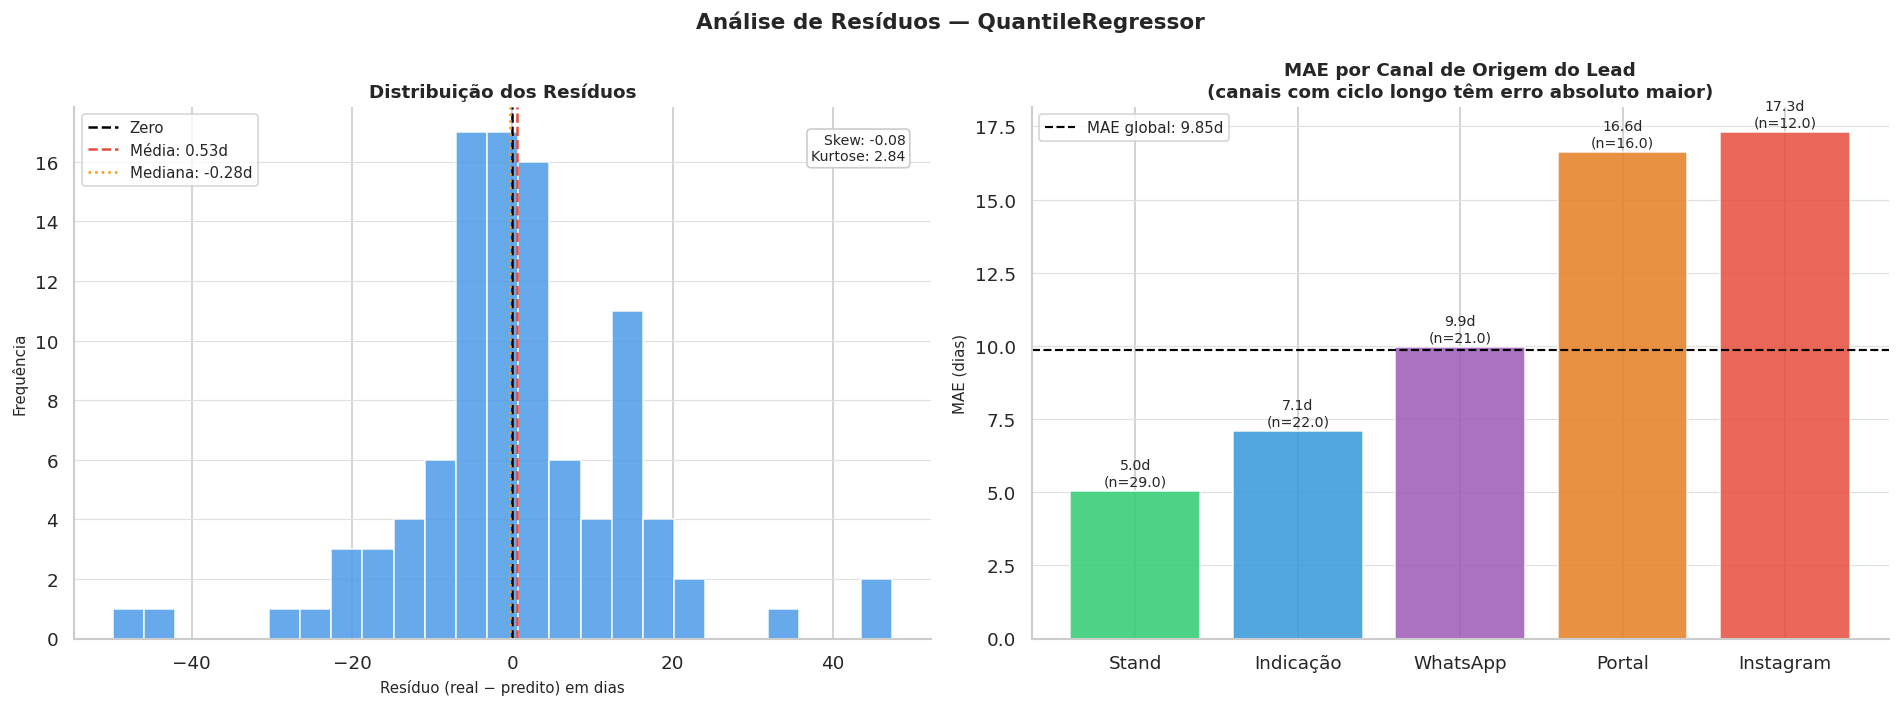

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── 1. Distribuição dos resíduos ─────────────────────────────────────────────
ax = axes[0]
ax.hist(residuos, bins=25, color="#4C9BE8", edgecolor="white", alpha=0.85)
ax.axvline(0,               color="black",   linestyle="--", linewidth=1.5, label="Zero")
ax.axvline(residuos.mean(), color="#E74C3C", linestyle="--", linewidth=1.5,
           label=f"Média: {residuos.mean():.2f}d")
ax.axvline(np.median(residuos), color="#F39C12", linestyle=":", linewidth=1.5,
           label=f"Mediana: {np.median(residuos):.2f}d")
ax.set_xlabel("Resíduo (real − predito) em dias")
ax.set_ylabel("Frequência")
ax.set_title("Distribuição dos Resíduos", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", color="#E0E0E0", linewidth=0.7)

skew_r = sp_stats.skew(residuos)
kurt_r = sp_stats.kurtosis(residuos)
ax.text(0.97, 0.95, f"Skew: {skew_r:.2f}\nKurtose: {kurt_r:.2f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=8.5,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#CCCCCC"))

# ── 2. MAE por canal de origem ───────────────────────────────────────────────
ax2 = axes[1]
test_eval = test_raw.copy().reset_index(drop=True)
test_eval["yhat"]    = yhat
test_eval["residuo"] = residuos

mae_canal = (
    test_eval.groupby("origem_lead")
    .apply(lambda g: pd.Series({
        "n":          len(g),
        "MAE":        mean_absolute_error(g[TARGET], g["yhat"]),
        "media_real": g[TARGET].mean(),
        "media_pred": g["yhat"].mean(),
    }))
    .reset_index()
    .sort_values("media_real")
)

cores_bar = [cores_canal[c] for c in mae_canal["origem_lead"]]
bars = ax2.bar(mae_canal["origem_lead"], mae_canal["MAE"],
               color=cores_bar, edgecolor="white", alpha=0.85)
ax2.axhline(mae_qr, color="black", linestyle="--", linewidth=1.3,
            label=f"MAE global: {mae_qr:.2f}d")

for bar, row in zip(bars, mae_canal.itertuples()):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
             f"{row.MAE:.1f}d\n(n={row.n})", ha="center", fontsize=8.5)

ax2.set_ylabel("MAE (dias)")
ax2.set_title("MAE por Canal de Origem do Lead\n(canais com ciclo longo têm erro absoluto maior)",
              fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(axis="y", color="#E0E0E0", linewidth=0.7)

fig.suptitle("Análise de Resíduos — QuantileRegressor", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

* Resíduos bem comportados globalmente. O modelo não carrega viés de direção.

* O modelo já entrega valor real para Stand e Indicação (erro < 1 semana). Para canais digitais, é necessário enriquecer o dataset com dados comportamentais de CRM antes de usar as previsões operacionalmente.

## 9.4. Conclusões e Recomendações

**O QUE O MODELO APRENDEU:**

  * Origem do lead é o principal driver do ciclo de venda
    (coeficientes OHE de canal dominam o modelo)

  * Instagram e Portal têm os maiores ciclos (+43d e +26d)

  * Stand e Indicação têm os menores ciclos

  * Valor do imóvel tem relação negativa (imóveis mais caros
    fecham ligeiramente mais rápido — efeito corretor/perfil)

  **ONDE O MODELO ERRA MAIS:**

  * Instagram (MAE=17.7d) e Portal (MAE=16.4d): alta variância
    intra-canal — leads digitais têm comportamento imprevisível

  * Stand e Indicação: MAE baixo (5.5d e 7.0d) — esses canais
    têm ciclos mais homogêneos e previsíveis

  **LIMITAÇÕES:**

  * O teto informacional do dataset é ~9.8d de MAE

  * 56% da variância residual não é explicada por nenhuma feature
